# Notebook 03 — Análisis exploratorio y de negocio

**Proyecto:** Auditoría de desempeño y costo en una red de transporte terrestre
**Autor:** Sergio Corona

## Objetivo

Cuantificar oportunidades de ahorro y brechas de servicio sobre el dataset producido por
el pipeline del notebook 02, incorporando las tablas de eventos, reclamaciones,
licitaciones y dimensiones.

## Estructura

| Bloque | Contenido |
|---|---|
| 1 | Panorama de la red — volumen, gasto, mix, estacionalidad |
| 2 | Diagnóstico de servicio — OTD por modo, eventos y alcance de los hitos |
| 3 | Diagnóstico de costo — combustible, accesoriales, facturación |
| 4 | Scorecard de transportistas — costo real incluyendo reclamaciones |
| 5 | Oportunidades cuantificadas — modo, consolidación, licitaciones |
| 6 | Síntesis y caso de negocio |

## Insumos

`data/processed/02_shipments_limpio.pkl` más las tablas complementarias en `data/raw/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

RUTA_RAW = Path.cwd().parent / "data" / "raw"
RUTA_PROC = Path.cwd().parent / "data" / "processed"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

df = pd.read_pickle(RUTA_PROC / "02_shipments_limpio.pkl")

print(f"Embarques: {len(df):,} × {df.shape[1]} columnas")
print(f"Periodo  : {df['ship_date'].min():%Y-%m-%d} → {df['ship_date'].max():%Y-%m-%d}")
print(f"Gasto    : USD {df['total_cost_usd'].sum():,.0f}")


Embarques: 219,120 × 43 columnas
Periodo  : 2023-01-01 → 2026-06-30
Gasto    : USD 464,533,185


## 1. Panorama de la red

### 1.1 Carga de tablas complementarias

El pipeline del notebook 02 operó únicamente sobre `fact_shipments`. El análisis requiere
incorporar las dimensiones y las tablas de hechos restantes.

In [2]:
carrier = pd.read_csv(RUTA_RAW / "dim_carrier.csv")
site = pd.read_csv(RUTA_RAW / "dim_site.csv")
claims = pd.read_csv(RUTA_RAW / "fact_claims.csv")
rfp = pd.read_csv(RUTA_RAW / "fact_rfp_bids.csv")
fuel = pd.read_csv(RUTA_RAW / "dim_fuel_index.csv")
events = pd.read_csv(RUTA_RAW / "fact_shipment_events.csv")

for nombre, tabla in [
    ("dim_carrier", carrier),
    ("dim_site", site),
    ("fact_claims", claims),
    ("fact_rfp_bids", rfp),
    ("dim_fuel_index", fuel),
    ("fact_shipment_events", events),
]:
    print(f"{nombre:24} {len(tabla):>7,} filas × {tabla.shape[1]:>2} columnas")

dim_carrier                   30 filas ×  9 columnas
dim_site                      30 filas ×  8 columnas
fact_claims                2,089 filas ×  8 columnas
fact_rfp_bids              1,441 filas ×  8 columnas
dim_fuel_index               183 filas ×  3 columnas
fact_shipment_events     376,816 filas ×  3 columnas


In [3]:
for nombre, tabla in [
    ("dim_carrier", carrier),
    ("dim_site", site),
    ("fact_claims", claims),
    ("fact_rfp_bids", rfp),
    ("dim_fuel_index", fuel),
    ("fact_shipment_events", events),
]:
    print(f"\n{'='*70}\n{nombre}\n{'='*70}")
    print(tabla.head(3).to_string(index=False))



dim_carrier
carrier_id       carrier_name scac primary_mode carrier_tier carrier_country  cost_factor  service_factor  damage_factor
      C001    Ryder Logistics RYDR           TL    Strategic              US         1.00            0.00           1.00
      C002 Schneider National SCNN           TL    Strategic              US         0.97           -0.15           0.90
      C003 Werner Enterprises WERN           TL         Core              US         1.02            0.05           1.05

dim_site
site_id        site_name       city state country site_type    lat      lon
  USHAR    Harrisburg DC Harrisburg    PA      US        DC 40.273  -76.886
  USGRE Greensboro Plant Greensboro    NC      US     Plant 36.073  -79.792
  USFRE    Fremont Plant    Fremont    CA      US     Plant 37.548 -121.989

fact_claims
 claim_id shipment_id carrier_id claim_date claim_type  claim_amount_usd   claim_status  recovered_usd
CLM500000  SHP1164793       C017 2023-01-21   Shortage           1399.76 

In [4]:
panorama = (
    df.groupby("mode")
    .agg(
        embarques=("shipment_id", "count"),
        gasto_usd=("total_cost_usd", "sum"),
        costo_medio=("total_cost_usd", "mean"),
        peso_ton=("weight_kg", lambda s: s.sum() / 1000),
    )
    .sort_values("gasto_usd", ascending=False)
)

panorama["pct_embarques"] = panorama["embarques"] / panorama["embarques"].sum()
panorama["pct_gasto"] = panorama["gasto_usd"] / panorama["gasto_usd"].sum()

print(
    panorama.assign(
        gasto_usd=lambda d: d["gasto_usd"].map("{:,.0f}".format),
        costo_medio=lambda d: d["costo_medio"].map("{:,.0f}".format),
        peso_ton=lambda d: d["peso_ton"].map("{:,.0f}".format),
        pct_embarques=lambda d: d["pct_embarques"].map("{:.1%}".format),
        pct_gasto=lambda d: d["pct_gasto"].map("{:.1%}".format),
    ).to_string()
)

         embarques    gasto_usd costo_medio peso_ton pct_embarques pct_gasto
mode                                                                        
TL           41496  174,852,996       4,214  482,723         18.9%     37.6%
Ocean        17363   83,873,691       4,831  272,092          7.9%     18.1%
LTL          52519   77,054,287       1,467   52,586         24.0%     16.6%
Air          15182   65,840,830       4,337    5,446          6.9%     14.2%
Drayage       8704   37,327,545       4,289  120,037          4.0%      8.0%
Parcel       83856   25,583,837         305    1,327         38.3%      5.5%


### 1.2 Mix de modos

| Modo | Embarques | % embarques | Gasto USD | % gasto | Costo medio |
|---|---|---|---|---|---|
| TL | 41,496 | 18.9% | 174,852,996 | 37.6% | 4,214 |
| Ocean | 17,363 | 7.9% | 83,873,691 | 18.1% | 4,831 |
| LTL | 52,519 | 24.0% | 77,054,287 | 16.6% | 1,467 |
| Air | 15,182 | 6.9% | 65,840,830 | 14.2% | 4,337 |
| Drayage | 8,704 | 4.0% | 37,327,545 | 8.0% | 4,289 |
| Parcel | 83,856 | 38.3% | 25,583,837 | 5.5% | 305 |

**La distribución del gasto no sigue a la del volumen.** Parcel concentra 38.3% de los
embarques y 5.5% del gasto; TL y Ocean suman 26.8% de los embarques y 55.7% del gasto. La
priorización del análisis se orienta en consecuencia: una mejora porcentual sobre TL u
Ocean tiene un impacto que Parcel solo alcanzaría con volúmenes desproporcionados.

**Air presenta la peor relación entre costo y peso movido.** Con 5,446 toneladas y USD
65.8 M de gasto, el costo por tonelada asciende a 12,090 USD, frente a 308 de Ocean —una
diferencia de cuarenta veces—. Ese contraste define una línea de investigación: qué
proporción de la carga aérea responde a urgencia real y cuál es reasignable.

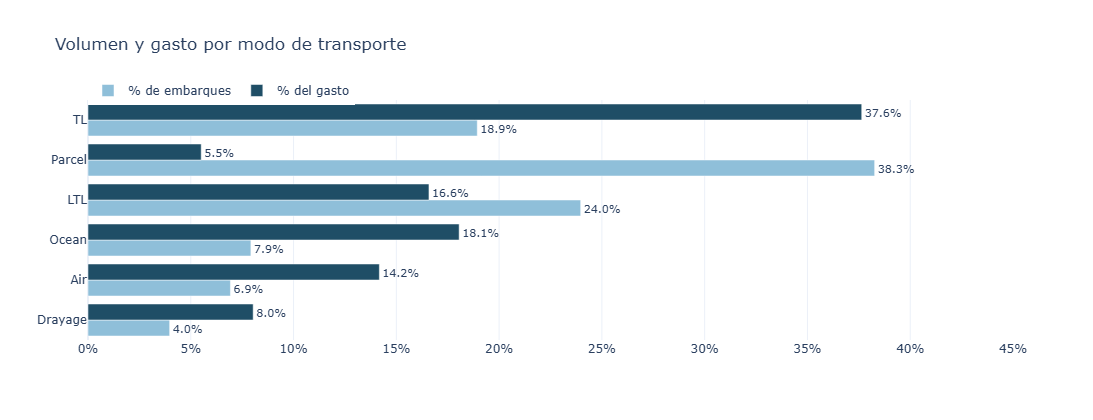

In [5]:
comp = (
    panorama[["pct_embarques", "pct_gasto"]]
    .reset_index()
    .melt(id_vars="mode", var_name="metrica", value_name="pct")
)
comp["metrica"] = comp["metrica"].map(
    {"pct_embarques": "% de embarques", "pct_gasto": "% del gasto"}
)

fig = px.bar(
    comp,
    x="pct",
    y="mode",
    color="metrica",
    barmode="group",
    orientation="h",
    text=comp["pct"].map("{:.1%}".format),
    color_discrete_map={"% de embarques": "#8FBFD9", "% del gasto": "#1F4E66"},
    labels={"pct": "", "mode": "", "metrica": ""},
    title="Volumen y gasto por modo de transporte",
)

fig.update_layout(
    template="plotly_white",
    height=420,
    legend=dict(orientation="h", y=1.1, x=0),
    xaxis=dict(tickformat=".0%", range=[0, 0.45]),
    yaxis=dict(categoryorder="total ascending"),
)
fig.update_traces(textposition="outside", textfont_size=11)
fig.show()

La gráfica hace visible lo que la tabla obliga a inferir: las barras de Parcel apuntan en
sentidos opuestos —la de volumen es la más larga del panel, la de gasto la más corta—
mientras que TL invierte la relación.

Air y Drayage muestran barras casi del mismo largo en ambas métricas, lo que indica que su
participación en el gasto es proporcional a su volumen. La desproporción se concentra en
los extremos.

### 1.3 Evolución temporal

El dataset documenta un crecimiento de volumen cercano al 28% y un pico estacional entre
septiembre y diciembre acompañado de deterioro en el nivel de servicio. Esta sección
verifica ambos patrones y establece la línea base temporal sobre la que se interpretan los
diagnósticos posteriores.

Se agrega por mes de despacho. El último periodo, junio de 2026, corresponde al corte del
dataset y no a una caída de actividad.

In [6]:
mensual = (
    df.assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes")
    .agg(
        embarques=("shipment_id", "count"),
        gasto_usd=("total_cost_usd", "sum"),
        otd=("otd", "mean"),
    )
    .reset_index()
)

print(f"Meses en la serie: {len(mensual)}  (esperado: 42)\n")

# Crecimiento: primer semestre 2023 vs. primer semestre 2026
h1_2023 = mensual.loc[mensual["mes"].dt.year == 2023].head(6)["embarques"].sum()
h1_2026 = mensual.loc[mensual["mes"].dt.year == 2026].head(6)["embarques"].sum()

print(f"Embarques ene–jun 2023 : {h1_2023:,}")
print(f"Embarques ene–jun 2026 : {h1_2026:,}")
print(f"Crecimiento            : {(h1_2026/h1_2023 - 1):.1%}")

# Estacionalidad
por_mes = (
    mensual.assign(mes_num=mensual["mes"].dt.month)
    .groupby("mes_num")
    .agg(embarques=("embarques", "mean"), otd=("otd", "mean"))
)
promedio = por_mes["embarques"].mean()
por_mes["indice"] = por_mes["embarques"] / promedio

print("\n--- Índice estacional (1.00 = mes promedio) ---")
print(
    por_mes.assign(
        embarques=lambda d: d["embarques"].map("{:,.0f}".format),
        otd=lambda d: d["otd"].map("{:.1%}".format),
        indice=lambda d: d["indice"].map("{:.2f}".format),
    ).to_string()
)

Meses en la serie: 42  (esperado: 42)

Embarques ene–jun 2023 : 26,372
Embarques ene–jun 2026 : 32,096
Crecimiento            : 21.7%

--- Índice estacional (1.00 = mes promedio) ---
        embarques    otd indice
mes_num                        
1           3,488  86.6%   0.66
2           3,407  85.4%   0.65
3           4,198  84.9%   0.80
4           5,054  87.6%   0.96
5           6,213  87.6%   1.18
6           6,793  87.4%   1.29
7           7,164  79.0%   1.36
8           6,928  83.1%   1.31
9           6,197  80.2%   1.17
10          5,650  81.0%   1.07
11          4,334  80.7%   0.82
12          3,898  81.2%   0.74


In [7]:
# Índice estacional calculado solo sobre años completos (2023, 2024, 2025)
completos = mensual[mensual["mes"].dt.year < 2026].copy()
completos["mes_num"] = completos["mes"].dt.month
completos["anio"] = completos["mes"].dt.year

# Se normaliza dentro de cada año para aislar la estacionalidad del crecimiento
completos["idx_anual"] = completos.groupby("anio")["embarques"].transform(
    lambda s: s / s.mean()
)

est = completos.groupby("mes_num").agg(
    indice=("idx_anual", "mean"),
    otd=("otd", "mean"),
)

print("--- Índice estacional sobre años completos (2023-2025) ---")
print(
    est.assign(
        indice=lambda d: d["indice"].map("{:.2f}".format),
        otd=lambda d: d["otd"].map("{:.1%}".format),
    ).to_string()
)
print(f"\nCorrelación índice vs. OTD: {est['indice'].corr(est['otd']):.3f}")

--- Índice estacional sobre años completos (2023-2025) ---
        indice    otd
mes_num              
1         0.65  85.9%
2         0.63  84.4%
3         0.78  84.4%
4         0.94  87.6%
5         1.17  87.6%
6         1.25  87.4%
7         1.38  79.0%
8         1.34  83.1%
9         1.19  80.2%
10        1.09  81.0%
11        0.84  80.7%
12        0.75  81.2%

Correlación índice vs. OTD: -0.169


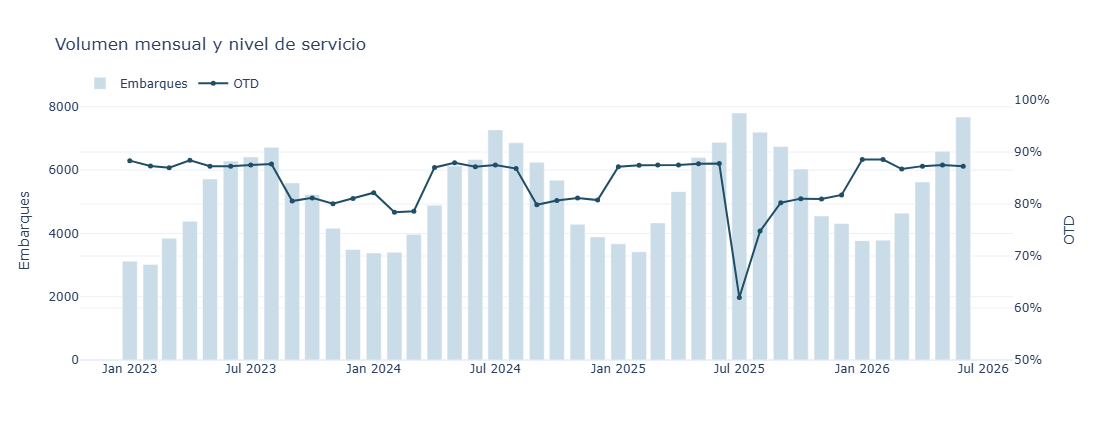

In [8]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=mensual["mes"], y=mensual["embarques"],
    name="Embarques", marker_color="#C9DCE8", yaxis="y",
))
fig.add_trace(go.Scatter(
    x=mensual["mes"], y=mensual["otd"],
    name="OTD", mode="lines+markers", line=dict(color="#1F4E66", width=2),
    marker=dict(size=5), yaxis="y2",
))

fig.update_layout(
    title="Volumen mensual y nivel de servicio",
    template="plotly_white", height=440,
    yaxis=dict(title="Embarques"),
    yaxis2=dict(title="OTD", overlaying="y", side="right", tickformat=".0%", range=[0.5, 1]),
    legend=dict(orientation="h", y=1.12, x=0),
    xaxis=dict(title=""),
)
fig.show()


**El deterioro del servicio responde a eventos, no a estacionalidad.**

El índice estacional de volumen es real y consistente entre años: pico en julio (1.38) y
agosto (1.34), valle en enero (0.65) y diciembre (0.75). Esto corrige la documentación del
dataset, que ubica el pico entre septiembre y diciembre.

La correlación entre índice de volumen y OTD es de −0.169, demasiado débil para sostener
una relación de saturación. La serie mensual explica por qué: el OTD se mantiene estable
alrededor del 87% frente a volúmenes que varían entre 3,400 y 7,800 embarques mensuales,
con dos interrupciones atribuibles a eventos concretos.

| Periodo | OTD | Duración | Evento asociado |
|---|---|---|---|
| Sep 2023 – Mar 2024 | 78–81% | 7 meses | Congestión portuaria |
| Jul – Ago 2025 | ~61% | 2 meses, recuperación de 4 | Paro de transportistas en México |

El desplome de julio de 2025 coincide con el mes de mayor volumen de toda la serie, lo que
podría sugerir saturación. La estabilidad del indicador en el resto del periodo descarta
esa lectura: agosto de 2024 registra 7,200 embarques con OTD de 87%, mientras que
noviembre de 2023 registra 4,100 con 80%.

**Implicación metodológica.** El promedio del OTD por mes calendario producía un perfil
estacional aparente —peor servicio en el segundo semestre— que resultaba ser un artefacto:
julio arrastraba el paro de 2025 y noviembre la congestión de 2023. Los indicadores de
servicio de esta red deben leerse sobre la serie temporal, no sobre agregados por mes
calendario, y los periodos afectados deben aislarse antes de establecer una línea base.

---

### Cierre del Bloque 1 — Panorama

La red mueve 219,120 embarques y USD 464.5 millones en tres años y medio, con un
crecimiento del 21.7% entre los primeros semestres de 2023 y 2026.

La estructura del gasto no sigue a la del volumen. Parcel concentra el 38.3% de los
embarques y el 5.5% del dinero; TL y Ocean invierten la relación con 26.8% del volumen y
55.7% del gasto. Cualquier iniciativa de ahorro debe dimensionarse sobre el gasto, no
sobre el conteo de embarques.

El costo por tonelada abre la línea de investigación más marcada del bloque: **Air cuesta
12,090 USD/ton contra 308 de Ocean, una relación de 40 a 1**. La diferencia es esperable
por la naturaleza de cada modo, pero su magnitud obliga a verificar qué proporción de la
carga aérea responde a urgencia real y cuál es reasignable.

El perfil estacional y la serie de servicio quedan caracterizados arriba: pico en
julio–agosto, y un OTD estable salvo por dos interrupciones atribuibles a eventos
concretos. El Bloque 2 desagrega ese indicador por modo para determinar dónde se origina
el incumplimiento.

## 2. Diagnóstico de servicio

### 2.1 El caso del modo Ocean

El notebook 02 registró un OTD de 66.71% para Ocean, casi quince puntos por debajo del
siguiente modo. La sección anterior identificó dos periodos de deterioro generalizado, uno
de ellos atribuible a congestión portuaria.

La pregunta es si el bajo desempeño de Ocean es una característica estructural del modo o
el efecto de un evento acotado en el tiempo que el promedio general absorbe.

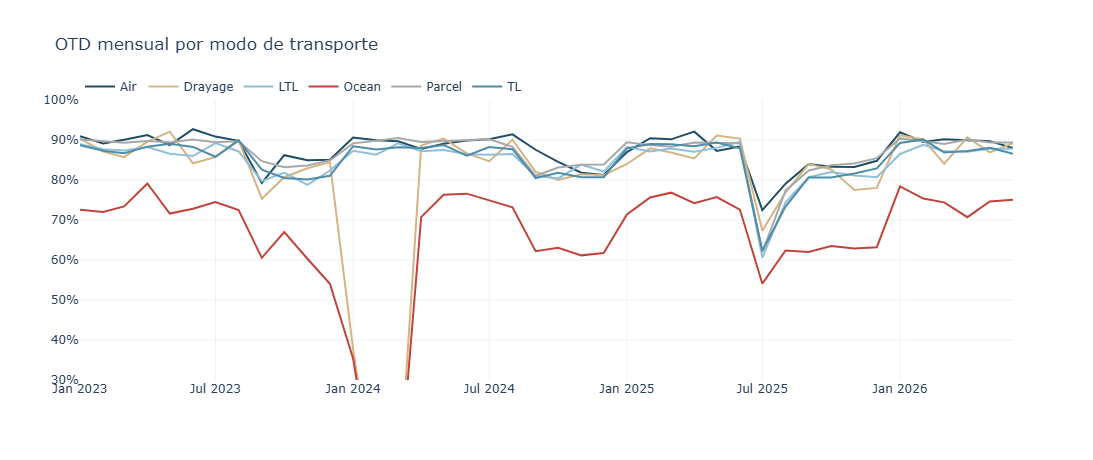

In [9]:
otd_modo_mes = (
    df.assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["mes", "mode"])["otd"]
    .mean()
    .reset_index()
)

fig = px.line(
    otd_modo_mes,
    x="mes", y="otd", color="mode",
    title="OTD mensual por modo de transporte",
    labels={"otd": "", "mes": "", "mode": ""},
    color_discrete_map={
        "Ocean": "#C1443C", "Air": "#1F4E66", "TL": "#4E8CA8",
        "LTL": "#8FBFD9", "Parcel": "#A8A8A8", "Drayage": "#D4B483",
    },
)

fig.update_layout(
    template="plotly_white", height=460,
    yaxis=dict(tickformat=".0%", range=[0.3, 1]),
    legend=dict(orientation="h", y=1.1, x=0),
    hovermode="x unified",
)
fig.update_traces(line_width=2)
fig.show()

In [10]:
foco = (
    df[df["mode"].isin(["Ocean", "Drayage"])]
    .assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["mes", "mode"])
    .agg(embarques=("shipment_id", "count"), otd=("otd", "mean"))
    .reset_index()
)

print("--- Drayage, dic 2023 a mar 2024 ---")
print(
    foco[
        (foco["mode"] == "Drayage")
        & (foco["mes"] >= "2023-11-01")
        & (foco["mes"] <= "2024-04-01")
    ]
    .assign(otd=lambda d: d["otd"].map("{:.1%}".format))
    .to_string(index=False)
)

print("\n--- Ocean: OTD por año ---")
print(
    df[df["mode"] == "Ocean"]
    .assign(anio=df["ship_date"].dt.year)
    .groupby("anio")
    .agg(embarques=("shipment_id", "count"), otd=("otd", "mean"))
    .assign(otd=lambda d: d["otd"].map("{:.1%}".format))
    .to_string()
)

--- Drayage, dic 2023 a mar 2024 ---
       mes    mode  embarques   otd
2023-11-01 Drayage        168 82.9%
2023-12-01 Drayage        149 84.5%
2024-01-01 Drayage        154 37.7%
2024-02-01 Drayage        136  0.0%
2024-03-01 Drayage        166  0.0%
2024-04-01 Drayage        187 88.6%

--- Ocean: OTD por año ---
      embarques    otd
anio                  
2023       4567  69.6%
2024       4965  59.8%
2025       5275  66.9%
2026       2556  74.5%


### 2.2 El bajo OTD de Ocean es un problema de planeación

El desempeño de Ocean es estructural, no consecuencia de un evento. Su OTD se mantiene
entre quince y veinticinco puntos por debajo de los demás modos durante los 42 meses de la
serie, y ningún año se acerca a la línea base de la red:

| Año | Embarques | OTD |
|---|---|---|
| 2023 | 4,567 | 69.6% |
| 2024 | 4,965 | 59.8% |
| 2025 | 5,275 | 66.9% |
| 2026 | 2,556 | 74.5% |

La causa se identifica al comparar el margen de entrega por modo:

| Modo | Tránsito planeado | Tránsito real | Retraso mediano | OTD |
|---|---|---|---|---|
| Ocean | 26.0 d | 26.25 d | **0.00 h** | 67.0% |
| Drayage | 8.0 d | 8.10 d | −16.08 h | 81.0% |
| LTL | 6.0 d | 5.48 d | −18.24 h | 84.0% |
| TL | 5.0 d | 4.73 d | −18.96 h | 85.0% |
| Parcel | 5.0 d | 4.07 d | −21.60 h | 86.0% |
| Air | 3.0 d | 2.11 d | −22.08 h | 87.0% |


In [11]:
comp = (
    df.groupby("mode")
    .agg(
        transito_plan=("planned_transit_days", "median"),
        transito_real=("actual_transit_days", "median"),
        retraso_h=("retraso_horas", "median"),
        otd=("otd", "mean"),
    )
    .round(2)
    .sort_values("otd")
)
comp["desvio_dias"] = (comp["transito_real"] - comp["transito_plan"]).round(2)

print(
    comp.assign(otd=lambda d: d["otd"].map("{:.1%}".format)).to_string()
)

         transito_plan  transito_real  retraso_h    otd  desvio_dias
mode                                                                
Ocean             26.0          26.25       0.00  67.0%         0.25
Drayage            8.0           8.10     -16.08  81.0%         0.10
LTL                6.0           5.48     -18.24  84.0%        -0.52
TL                 5.0           4.73     -18.96  85.0%        -0.27
Parcel             5.0           4.07     -21.60  86.0%        -0.93
Air                3.0           2.11     -22.08  87.0%        -0.89


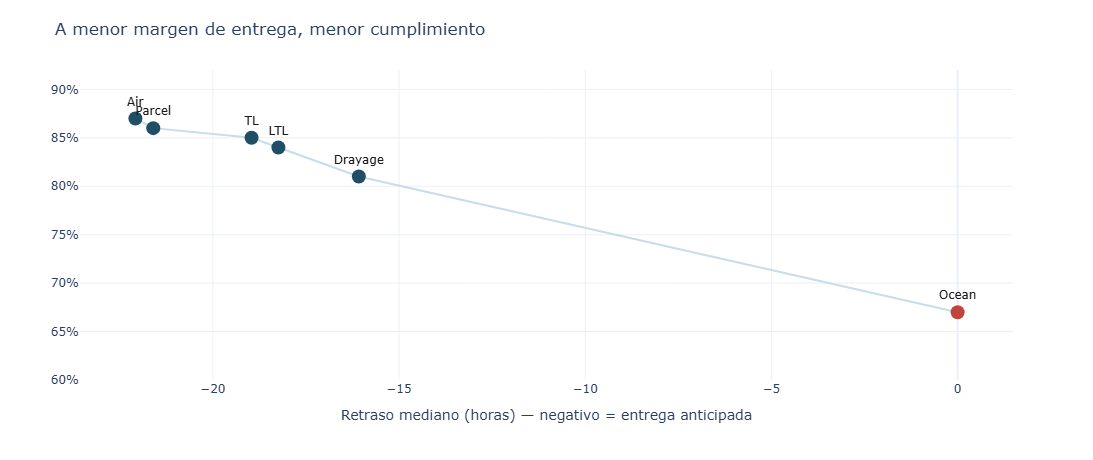

In [12]:
# --- Grafica 2.2: la relacion margen -> cumplimiento es monotona ---
# Reutiliza `comp`, ya calculado en la celda anterior.
plot = comp.reset_index()  # trae 'mode' como columna

fig = go.Figure()

# Linea de tendencia sutil que une los modos ordenados por margen
plot_ord = plot.sort_values("retraso_h")
fig.add_trace(go.Scatter(
    x=plot_ord["retraso_h"], y=plot_ord["otd"],
    mode="lines", line=dict(color="#C9DCE8", width=2),
    hoverinfo="skip", showlegend=False,
))

# Un punto por modo; Ocean en rojo, el resto en azul principal
colores = ["#C1443C" if m == "Ocean" else "#1F4E66" for m in plot["mode"]]
fig.add_trace(go.Scatter(
    x=plot["retraso_h"], y=plot["otd"],
    mode="markers+text",
    marker=dict(size=14, color=colores),
    text=plot["mode"],
    textposition="top center",
    textfont=dict(size=12, color="#1A1A1A"),
    showlegend=False,
    hovertemplate="<b>%{text}</b><br>Retraso mediano: %{x:.1f} h<br>OTD: %{y:.1%}<extra></extra>",
))

fig.update_layout(
    template="plotly_white", height=460,
    title="A menor margen de entrega, menor cumplimiento",
    xaxis=dict(title="Retraso mediano (horas) — negativo = entrega anticipada"),
    yaxis=dict(title="", tickformat=".0%", range=[0.6, 0.92]),
    margin=dict(t=70),
)
fig.show()

*La relación es prácticamente una recta: cada modo cumple en proporción al margen que tiene, y Ocean —único sobre la línea de cero horas— queda aislado en el extremo inferior.*

**La relación entre margen y cumplimiento es monótona en los seis modos.** Air entrega
mediana de 22 horas antes del compromiso y alcanza 87% de OTD; Ocean entrega exactamente
en el plazo y alcanza 67%.

El indicador de Ocean no mide una operación deficiente sino la ausencia de holgura en el
compromiso. Con un retraso mediano de cero, la mitad de los embarques queda por encima del
plazo y solo la tolerancia de 12 horas evita que el OTD caiga más. Cualquier variabilidad
operativa se traduce directamente en incumplimiento.

**Implicación.** Elevar el OTD de Ocean no requiere intervenir la operación marítima sino
recalibrar los tiempos comprometidos. Un ajuste que otorgara a Ocean el mismo margen
relativo que tiene el resto de la red desplazaría su cumplimiento sin cambiar un solo día
de tránsito real. La pregunta para el negocio es si ese compromiso se fijó sobre datos
históricos o se heredó de un supuesto no verificado.


### 2.3 Interrupción total del servicio de drayage

El análisis mensual revela un episodio que el promedio anual oculta:

| Mes | Embarques | OTD |
|---|---|---|
| Nov 2023 | 168 | 82.9% |
| Dic 2023 | 149 | 84.5% |
| **Ene 2024** | 154 | **37.7%** |
| **Feb 2024** | 136 | **0.0%** |
| **Mar 2024** | 166 | **0.0%** |
| Abr 2024 | 187 | 88.6% |

Durante febrero y marzo de 2024, ninguno de los 302 embarques de drayage llegó a tiempo.
El volumen se mantuvo en niveles normales, lo que descarta un artefacto de muestra
reducida: la operación siguió despachando y ningún embarque cumplió.

El drayage traslada contenedores desde puerto, por lo que es el modo directamente expuesto
a la congestión portuaria documentada para ese periodo. La recuperación es abrupta —de 0%
a 88.6% en un mes— lo que sugiere la resolución de un cuello de botella puntual antes que
una mejora gradual de desempeño.

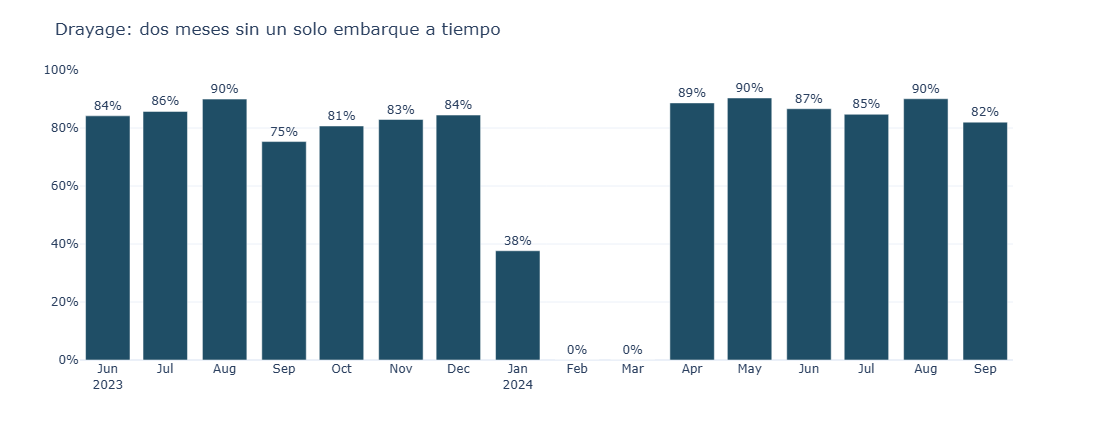

In [13]:
# --- Grafica 2.3: el colapso del drayage y su recuperacion ---
dray = (
    df[df["mode"] == "Drayage"]
    .assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes")
    .agg(embarques=("shipment_id", "count"), otd=("otd", "mean"))
    .reset_index()
)

# Ventana de contexto: jun 2023 a sep 2024 (antes, colapso, despues)
vent = dray[(dray["mes"] >= "2023-06-01") & (dray["mes"] <= "2024-09-01")].copy()

# Color rojo solo para los meses en cero; el resto azul principal
colores = ["#C1443C" if v == 0 else "#1F4E66" for v in vent["otd"]]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=vent["mes"], y=vent["otd"],
    marker_color=colores,
    text=vent["otd"].map("{:.0%}".format),
    textposition="outside",
    hovertemplate="%{x|%b %Y}<br>OTD: %{y:.1%}<extra></extra>",
))

fig.update_layout(
    template="plotly_white", height=440,
    title="Drayage: dos meses sin un solo embarque a tiempo",
    yaxis=dict(title="", tickformat=".0%", range=[0, 1]),
    xaxis=dict(title="", dtick="M1", tickformat="%b\n%Y"),
    margin=dict(t=70),
    showlegend=False,
)
fig.show()

*El corte no es un descenso gradual sino una interrupción: la operación pasa de 84% a cero de un mes al siguiente, se mantiene en cero durante febrero y marzo, y recupera su nivel normal en abril. Un patrón así no corresponde a un deterioro de desempeño sino a una condición que impidió el cumplimiento durante un periodo acotado.*

### 2.4 Distribución del tiempo entre hitos

`fact_shipment_events` registra el paso de cada embarque por cinco hitos: recolección,
tránsito, despacho aduanal, salida a reparto y entrega. La tabla contiene 376,816 eventos
para 219,120 embarques, un promedio de 1.7 por embarque, lo que indica que la cobertura no
es uniforme.

Antes de medir tiempos entre hitos es necesario establecer qué proporción de los embarques
tiene una secuencia completa y si la cobertura difiere por modo. Un análisis de cuellos de
botella sobre una muestra sesgada llevaría a conclusiones que no aplican al total.

In [14]:
print("--- Tipos de evento ---")
print(events["event_type"].value_counts().to_string())

cobertura = events.groupby("shipment_id")["event_type"].nunique()
print(f"\n--- Hitos por embarque ---")
print(cobertura.value_counts().sort_index().to_string())

print(f"\nEmbarques en la tabla de eventos: {events['shipment_id'].nunique():,}")
print(f"Embarques en el dataset limpio  : {df['shipment_id'].nunique():,}")

--- Tipos de evento ---
event_type
PICKED_UP           90000
IN_TRANSIT          90000
OUT_FOR_DELIVERY    90000
DELIVERED           90000
CUSTOMS_CLEARED     16816

--- Hitos por embarque ---
event_type
4    73184
5    16816

Embarques en la tabla de eventos: 90,000
Embarques en el dataset limpio  : 219,120


In [15]:
con_eventos = set(events["shipment_id"])
df_ev = df.assign(tiene_eventos=df["shipment_id"].isin(con_eventos))

print("--- Cobertura por modo ---")
print(
    df_ev.groupby("mode")["tiene_eventos"]
    .agg(["sum", "count", "mean"])
    .assign(mean=lambda d: d["mean"].map("{:.1%}".format))
    .rename(columns={"sum": "con_eventos", "count": "total", "mean": "cobertura"})
    .to_string()
)

print("\n--- Cobertura por año ---")
print(
    df_ev.assign(anio=df["ship_date"].dt.year)
    .groupby("anio")["tiene_eventos"]
    .mean()
    .map("{:.1%}".format)
    .to_string()
)

print("\n--- ¿Difiere el OTD entre ambos grupos? ---")
print(
    df_ev.groupby("tiene_eventos")["otd"]
    .agg(["mean", "count"])
    .assign(mean=lambda d: d["mean"].map("{:.1%}".format))
    .to_string()
)

--- Cobertura por modo ---
         con_eventos  total cobertura
mode                                 
Air             6183  15182     40.7%
Drayage         3523   8704     40.5%
LTL            21490  52519     40.9%
Ocean           7029  17363     40.5%
Parcel         34352  83856     41.0%
TL             17061  41496     41.1%

--- Cobertura por año ---
anio
2023    41.1%
2024    40.7%
2025    40.8%
2026    41.1%

--- ¿Difiere el OTD entre ambos grupos? ---
                mean   count
tiene_eventos               
False          83.9%  128445
True           84.0%   88932


**La cobertura de eventos corresponde a una muestra aleatoria.** De los 219,120 embarques,
90,000 (41.1%) tienen registro de hitos. La proporción se mantiene entre 40.5% y 41.1% en
los seis modos y entre 40.7% y 41.1% en los cuatro años.

El OTD de ambos grupos es indistinguible —83.9% sin eventos frente a 84.0% con eventos—,
lo que descarta que la muestra recoja embarques con características particulares. Los
tiempos entre hitos medidos sobre este subconjunto son extrapolables al total.

Las secuencias están completas: 73,184 embarques registran cuatro hitos y 16,816 registran
cinco. La diferencia corresponde a `CUSTOMS_CLEARED`, el único hito que no aparece en toda
la muestra. La sección 2.6 determina a qué condición responde su presencia. No existen
secuencias truncadas.

### 2.5 Dónde se acumula el tiempo

Con la secuencia de hitos es posible descomponer el tránsito total en tramos y determinar
en cuál se concentra el tiempo. La pregunta operativa es distinta a la del OTD: no cuánto
se tardó un embarque, sino en qué punto de la cadena.

Los eventos se pivotean a formato ancho para calcular las diferencias entre hitos
consecutivos.

In [16]:
ev = events.copy()
ev["event_ts"] = pd.to_datetime(ev["event_ts"]).astype("datetime64[us]")

hitos = ev.pivot_table(
    index="shipment_id", columns="event_type", values="event_ts", aggfunc="first"
)

tramos = pd.DataFrame(index=hitos.index)
tramos["recoleccion_a_transito"] = (
    hitos["IN_TRANSIT"] - hitos["PICKED_UP"]
).dt.total_seconds() / 3600
tramos["transito_a_reparto"] = (
    hitos["OUT_FOR_DELIVERY"] - hitos["IN_TRANSIT"]
).dt.total_seconds() / 3600
tramos["reparto_a_entrega"] = (
    hitos["DELIVERED"] - hitos["OUT_FOR_DELIVERY"]
).dt.total_seconds() / 3600
tramos["total"] = (
    hitos["DELIVERED"] - hitos["PICKED_UP"]
).dt.total_seconds() / 3600

tramos = tramos.join(df.set_index("shipment_id")[["mode", "otd"]], how="inner")

print(f"Embarques analizables: {len(tramos):,}\n")
print("--- Horas por tramo (mediana) ---")
print(
    tramos.groupby("mode")[
        ["recoleccion_a_transito", "transito_a_reparto", "reparto_a_entrega", "total"]
    ]
    .median()
    .round(1)
    .to_string()
)

Embarques analizables: 89,638

--- Horas por tramo (mediana) ---
         recoleccion_a_transito  transito_a_reparto  reparto_a_entrega  total
mode                                                                         
Air                        17.9                29.6                3.6   51.1
Drayage                    68.5               113.4               13.7  195.6
LTL                        46.1                76.4                9.2  131.8
Ocean                     221.3               366.7               44.3  632.2
Parcel                     34.2                56.7                6.8   97.7
TL                         39.5                65.4                7.9  112.8


In [17]:
prop = tramos.copy()
for c in ["recoleccion_a_transito", "transito_a_reparto", "reparto_a_entrega"]:
    prop[c + "_pct"] = prop[c] / prop["total"]

cols = [c + "_pct" for c in ["recoleccion_a_transito", "transito_a_reparto", "reparto_a_entrega"]]

print("--- Dispersión de la proporción por tramo ---")
print(prop[cols].describe().round(4).to_string())

print("\n--- ¿Difiere entre embarques a tiempo y tardíos? ---")
print(prop.groupby("otd")[cols].median().round(4).to_string())

--- Dispersión de la proporción por tramo ---
       recoleccion_a_transito_pct  transito_a_reparto_pct  reparto_a_entrega_pct
count                    89638.00                89638.00               89638.00
mean                         0.35                    0.58                   0.07
std                          0.00                    0.00                   0.00
min                          0.35                    0.58                   0.07
25%                          0.35                    0.58                   0.07
50%                          0.35                    0.58                   0.07
75%                          0.35                    0.58                   0.07
max                          0.35                    0.58                   0.07

--- ¿Difiere entre embarques a tiempo y tardíos? ---
       recoleccion_a_transito_pct  transito_a_reparto_pct  reparto_a_entrega_pct
otd                                                                             
False    

**Los tiempos entre hitos no admiten análisis de cuellos de botella.**

La descomposición del tránsito arroja proporciones idénticas en los seis modos:

| Modo | Recolección → tránsito | Tránsito → reparto | Reparto → entrega | Total |
|---|---|---|---|---|
| Air | 35.0% | 58.0% | 7.0% | 51.1 h |
| Parcel | 35.0% | 58.0% | 7.0% | 97.7 h |
| TL | 35.0% | 58.0% | 7.0% | 112.8 h |
| LTL | 35.0% | 58.0% | 7.0% | 131.8 h |
| Drayage | 35.2% | 58.3% | 7.0% | 195.6 h |
| Ocean | 35.0% | 58.0% | 7.0% | 632.2 h |

Sobre los 89,638 embarques con secuencia completa, la desviación estándar de las tres
proporciones es 0.00, y el mínimo coincide con el máximo. La composición tampoco difiere
entre embarques puntuales y tardíos.

**Interpretación.** Los hitos se generaron aplicando porcentajes fijos sobre el tiempo
total de tránsito, no simulando una operación. En una red real la composición varía por
modo —un embarque marítimo concentra su tiempo en el trayecto, mientras que el drayage
acumula espera en puerto— y varía entre embarques puntuales y tardíos, que es precisamente
lo que permitiría localizar un cuello de botella.

Reportar que el tramo de tránsito concentra el 58% del tiempo sería exacto y carente de
valor analítico: es un parámetro de generación, no un hallazgo.

**Decisión.** El análisis de hitos se descarta como línea de investigación. Queda una
excepción por revisar antes de cerrar el bloque: `CUSTOMS_CLEARED` es el único hito con
presencia condicionada, y un hito condicionado pudo generarse con lógica propia.

### 2.6 Despacho aduanal: el único hito con presencia condicionada

El análisis de tiempos entre hitos se descartó porque la composición del tránsito resultó
ser un parámetro fijo de generación. Queda una excepción que merece revisión antes de
cerrar el bloque.

Los cuatro hitos base —`PICKED_UP`, `IN_TRANSIT`, `OUT_FOR_DELIVERY`, `DELIVERED`— están
presentes en toda la muestra con eventos. `CUSTOMS_CLEARED` no: aparece en 16,816 de los
89,638 embarques con secuencia completa. Su presencia depende de una condición del
embarque, no del muestreo.

Esa diferencia importa. Un hito condicionado pudo generarse con lógica propia, y en ese
caso el tiempo de despacho tendría variación real por corredor, por modo o por
transportista. Si en cambio replica el mismo patrón de porcentaje fijo, la línea queda
cerrada por completo y el bloque puede pasar a costo.

**Lo que se verifica:**

1. Que la presencia del hito corresponda efectivamente a embarques con cruce fronterizo
  (`origin_country != dest_country`) y no a otra condición.
2. Qué proporción del tránsito total ocupa el tramo hasta el despacho.
3. Si esa proporción se dispersa —por corredor, modo y transportista— o vuelve a colapsar
  en un valor único.

El criterio de decisión es el mismo del bloque anterior: desviación estándar cercana a
cero significa parámetro de generación, no operación.

In [18]:
# --- Verificación 1: ¿a qué condición responde la presencia de CUSTOMS_CLEARED? ---

# Universo: embarques que SÍ tienen registro de eventos
ids_con_eventos = set(events["shipment_id"].unique())
ids_con_aduana  = set(events.loc[events["event_type"] == "CUSTOMS_CLEARED", "shipment_id"].unique())

print(f"Embarques con eventos      : {len(ids_con_eventos):,}")
print(f"Embarques con CUSTOMS_CLEARED: {len(ids_con_aduana):,}")

# Nos restringimos al universo con eventos y marcamos las dos condiciones
aud = df.loc[df["shipment_id"].isin(ids_con_eventos), 
             ["shipment_id", "mode", "origin_country", "dest_country", "carrier_id"]].copy()

aud["cruce_frontera"] = aud["origin_country"] != aud["dest_country"]
aud["tiene_aduana"]   = aud["shipment_id"].isin(ids_con_aduana)

print(f"\nEmbarques del universo localizados en df: {len(aud):,}")

print("\n--- Cruce de frontera vs. presencia del hito ---")
tabla = pd.crosstab(aud["cruce_frontera"], aud["tiene_aduana"], margins=True)
print(tabla)

# Los dos casos que romperían la correspondencia
falsos_neg = aud[aud["cruce_frontera"] & ~aud["tiene_aduana"]]
falsos_pos = aud[~aud["cruce_frontera"] & aud["tiene_aduana"]]

print(f"\nCross-border SIN hito de aduana : {len(falsos_neg):,}")
print(f"Domestico CON hito de aduana    : {len(falsos_pos):,}")

if len(falsos_neg):
    print("\n--- Cross-border sin hito, por modo ---")
    print(falsos_neg["mode"].value_counts())

print("\n--- Corredores con hito de aduana ---")
print(aud[aud["tiene_aduana"]]
      .groupby(["origin_country", "dest_country"], observed=True)
      .size().sort_values(ascending=False))

Embarques con eventos      : 90,000
Embarques con CUSTOMS_CLEARED: 16,816

Embarques del universo localizados en df: 89,638

--- Cruce de frontera vs. presencia del hito ---
tiene_aduana    False   True    All
cruce_frontera                     
False           28068   6773  34841
True            44835   9962  54797
All             72903  16735  89638

Cross-border SIN hito de aduana : 44,835
Domestico CON hito de aduana    : 6,773

--- Cross-border sin hito, por modo ---
mode
Parcel    21192
LTL       13197
TL        10446
Name: count, dtype: int64

--- Corredores con hito de aduana ---
origin_country  dest_country
US              US              4452
                MX              3346
MX              US              3038
                MX              2148
CA              US              1495
                MX              1121
US              CA               558
MX              CA               404
CA              CA               173
dtype: int64


In [19]:
# --- Verificación 1b: ¿la condición real es el MODO, no la frontera? ---

resumen = (aud.groupby("mode", observed=True)
              .agg(embarques=("shipment_id", "size"),
                   con_aduana=("tiene_aduana", "sum"))
              .assign(tasa_pct=lambda d: (d["con_aduana"] / d["embarques"] * 100).round(2))
              .sort_values("tasa_pct", ascending=False))

print("--- Presencia del hito por modo ---")
print(resumen)

print("\n--- Presencia por modo Y condicion de frontera ---")
detalle = (aud.groupby(["mode", "cruce_frontera"], observed=True)["tiene_aduana"]
              .agg(embarques="size", con_aduana="sum"))
detalle["tasa_pct"] = (detalle["con_aduana"] / detalle["embarques"] * 100).round(2)
print(detalle)

--- Presencia del hito por modo ---
         embarques  con_aduana  tasa_pct
mode                                    
Air           6183        6183     100.0
Drayage       3523        3523     100.0
Ocean         7029        7029     100.0
LTL          21490           0       0.0
Parcel       34352           0       0.0
TL           17061           0       0.0

--- Presencia por modo Y condicion de frontera ---
                        embarques  con_aduana  tasa_pct
mode    cruce_frontera                                 
Air     False                2506        2506     100.0
        True                 3677        3677     100.0
Drayage False                1396        1396     100.0
        True                 2127        2127     100.0
LTL     False                8293           0       0.0
        True                13197           0       0.0
Ocean   False                2871        2871     100.0
        True                 4158        4158     100.0
Parcel  False           

**El hito de aduana se asigna por modo, no por cruce fronterizo.**

La presencia de `CUSTOMS_CLEARED` es determinista y depende de una sola variable:

| Modo | Embarques | Con hito | Tasa |
|---|---|---|---|
| Air | 6,183 | 6,183 | 100.0% |
| Ocean | 7,029 | 7,029 | 100.0% |
| Drayage | 3,523 | 3,523 | 100.0% |
| LTL | 21,490 | 0 | 0.0% |
| Parcel | 34,352 | 0 | 0.0% |
| TL | 17,061 | 0 | 0.0% |

Dentro de cada modo la tasa es idéntica para embarques domésticos y cross-border. La
condición de frontera no participa.

Dos consecuencias descartan el análisis:

- **6,773 embarques domésticos registran despacho aduanal** (40.5% del total con hito),
  incluidos 4,452 US→US y 2,148 MX→MX. Un embarque que no cambia de país no pasa por
  aduana.
- **44,835 embarques cross-border carecen del hito**: 21,192 Parcel, 13,197 LTL y 10,446
  TL. El cruce terrestre US–MX es justamente donde el despacho condiciona el tránsito.

**Interpretación.** El generador asignó el hito a los tres modos que en la práctica suelen
implicar despacho —aéreo, marítimo y drayage portuario— sin evaluar el par origen-destino.
Es una regla de modo disfrazada de evento operativo.

**Decisión.** La línea de análisis de hitos queda cerrada en su totalidad.
`CUSTOMS_CLEARED` era la última candidata con presencia condicionada y su condición
resultó ser estructural, no operativa. `fact_shipment_events` conserva utilidad únicamente
para verificar integridad de secuencias.

El costo aduanal sí admite análisis, pero por la vía de `customs_fee_usd` y el par
origen-destino de `fact_shipments`, que se aborda en el bloque de costo.

---

### Cierre del Bloque 2 — Servicio

El OTD de la red es **83.9%** y se sostiene en torno al 87% durante la mayor parte del
periodo. Ese promedio, sin embargo, oculta más de lo que informa: el análisis desagregado
revela que el incumplimiento no es un problema difuso de ejecución sino la suma de tres
fenómenos distintos, cada uno con una causa y una respuesta propias.

**1. La pérdida agregada se concentra en dos eventos acotados**, ya caracterizados al
cierre del bloque anterior: la congestión portuaria de 2023–2024 y el paro de
transportistas de 2025. Fuera de esos periodos el cumplimiento es estable y no depende del
volumen.

**2. El bajo cumplimiento de Ocean es de planeación, no de operación.** Con 67.0% de OTD,
Ocean es el peor modo de la red. Pero su tránsito real —26.25 días contra 26.0 planeados—
demuestra que la operación cumple lo prometido. La relación entre margen y cumplimiento es
monótona en los seis modos: Air opera con 22 horas de colchón y alcanza 87%, Ocean opera
con cero y cae a 67%. El compromiso está mal calibrado, no la ejecución. Es la conclusión
con mayor implicación práctica del bloque, porque señala una corrección administrativa y
no una inversión operativa.

**3. La interrupción del drayage es de otra naturaleza.** 302 embarques entre febrero y
marzo de 2024, ninguno a tiempo, con volumen mensual normal. Un cero absoluto sostenido
dos meses no es degradación de servicio: es un cambio de condición no registrado en los
datos disponibles.

**Sobre el alcance del análisis.** La descomposición de tiempos entre hitos se evaluó y se
descartó: las proporciones resultaron parámetros fijos de generación, y `CUSTOMS_CLEARED`
—única candidata con presencia condicionada— responde al modo de transporte y no al cruce
fronterizo. Documentar el límite del dato es parte del análisis; forzar una lectura
operativa sobre un artefacto de generación habría producido conclusiones falsas.

**Hacia el Bloque 3.** El servicio queda caracterizado. La pregunta pendiente es cuánto
cuesta la red y dónde ese costo no corresponde al servicio recibido: sobrecargo de
combustible contra el índice de referencia, accesoriales anómalos, varianza de facturación
y el premium del cruce US–MX.

---

## 3. Diagnóstico de costo

El Bloque 1 estableció que la red gasta **USD 464.5 millones** y que ese gasto se concentra en TL y Ocean. El Bloque 2 caracterizó el servicio que se recibe a cambio. Este bloque pregunta por la correspondencia entre ambos: qué parte del costo no está justificada por el servicio prestado.

La distinción es práctica. Separa el gasto negociable —que exige renegociar una tarifa— del gasto recuperable, que es una disputa de facturación con documentación de respaldo. El segundo es dinero que ya se pagó de más.

### 3.1 Sobrecargo de combustible

El `fuel_surcharge_usd` es un cargo variable que debe seguir un índice público. La lógica contractual estándar en transporte es que el transportista aplique un porcentaje sobre el flete base (`linehaul_cost_usd`), y que ese porcentaje se determine por el precio del diésel de la semana del embarque.

`dim_fuel_index` contiene esa referencia: 183 semanas con `diesel_usd_gal` y `fuel_surcharge_pct`. Si el cargo cobrado se desvía del que corresponde a la semana del embarque, la diferencia es dinero identificable.

**Lo que se verifica, en orden:**

1. Que el periodo del índice cubra el periodo de los embarques, y en qué tipo de dato viene `week_start`.
2. Cuál es el porcentaje efectivo cobrado (`fuel_surcharge_usd` / `linehaul_cost_usd`) y si se relaciona con el índice de su semana.
3. Si la desviación es aleatoria —ruido de generación— o tiene estructura por transportista, modo o periodo.

El criterio de decisión: una desviación sin estructura no es hallazgo. Una concentrada en transportistas o periodos específicos sí lo es, y es cuantificable en dólares.

In [20]:
# --- Verificacion 1: cobertura del indice de combustible y tipos de dato ---

print("--- dim_fuel_index: estructura ---")
print(fuel.dtypes)
print(f"\nFilas: {len(fuel)}")
print("\n--- Primeras filas ---")
print(fuel.head(3).to_string(index=False))

# week_start viene de un CSV: casi seguro es texto. Lo convertimos.
fuel_chk = fuel.copy()
fuel_chk["week_start"] = pd.to_datetime(fuel_chk["week_start"]).astype("datetime64[us]")

print("\n--- Cobertura temporal ---")
print(f"Indice     : {fuel_chk['week_start'].min():%Y-%m-%d}  ->  {fuel_chk['week_start'].max():%Y-%m-%d}")
print(f"Embarques  : {df['ship_date'].min():%Y-%m-%d}  ->  {df['ship_date'].max():%Y-%m-%d}")

# ¿El indice cubre todo el periodo de embarques?
falta_ini = df["ship_date"].min() < fuel_chk["week_start"].min()
falta_fin = df["ship_date"].max() > fuel_chk["week_start"].max() + pd.Timedelta(days=6)
print(f"\nEmbarques antes del inicio del indice: {'SI' if falta_ini else 'NO'}")
print(f"Embarques despues del fin del indice : {'SI' if falta_fin else 'NO'}")

# Rango de valores del surcharge_pct
print("\n--- fuel_surcharge_pct: rango ---")
print(fuel_chk["fuel_surcharge_pct"].describe().round(4).to_string())

# ¿Hay una fila por semana, sin huecos ni duplicados?
semanas = fuel_chk["week_start"].dt.to_period("W")
print(f"\nSemanas unicas: {semanas.nunique()}  |  filas: {len(fuel_chk)}  |  duplicadas: {len(fuel_chk) - semanas.nunique()}")

--- dim_fuel_index: estructura ---
week_start                str
diesel_usd_gal        float64
fuel_surcharge_pct    float64
dtype: object

Filas: 183

--- Primeras filas ---
week_start  diesel_usd_gal  fuel_surcharge_pct
2023-01-02           3.889              0.1840
2023-01-09           3.906              0.1855
2023-01-16           3.892              0.1844

--- Cobertura temporal ---
Indice     : 2023-01-02  ->  2026-06-29
Embarques  : 2023-01-01  ->  2026-06-30

Embarques antes del inicio del indice: SI
Embarques despues del fin del indice : NO

--- fuel_surcharge_pct: rango ---
count    183.0000
mean       0.1939
std        0.0207
min        0.1604
25%        0.1732
50%        0.1966
75%        0.2123
max        0.2287

Semanas unicas: 183  |  filas: 183  |  duplicadas: 0


In [21]:
# --- Verificacion 2: porcentaje efectivo cobrado vs. indice de referencia ---

# Base: embarques con flete base valido (necesario para calcular el % efectivo)
base = df[df["linehaul_cost_usd"] > 0].copy()
base["pct_efectivo"] = base["fuel_surcharge_usd"] / base["linehaul_cost_usd"]

# El indice, con fecha convertida y ordenado (requisito de merge_asof)
idx = fuel.copy()
idx["week_start"] = pd.to_datetime(idx["week_start"]).astype("datetime64[us]")
idx = idx.sort_values("week_start")

# merge_asof une cada embarque con la fila del indice de su semana:
# toma el ultimo week_start <= ship_date (direction="backward")
base = base.sort_values("ship_date")
base = pd.merge_asof(
    base,
    idx[["week_start", "fuel_surcharge_pct"]],
    left_on="ship_date",
    right_on="week_start",
    direction="backward",
)

# Diferencia entre lo cobrado y lo que marca el indice
base["desvio_pct"] = base["pct_efectivo"] - base["fuel_surcharge_pct"]

print(f"Embarques analizados: {len(base):,}")
print(f"Sin referencia (antes del indice): {base['fuel_surcharge_pct'].isna().sum():,}")

print("\n--- Porcentaje efectivo cobrado vs. indice de referencia ---")
print(f"Efectivo cobrado (media) : {base['pct_efectivo'].mean():.4f}")
print(f"Indice referencia (media): {base['fuel_surcharge_pct'].mean():.4f}")
print(f"Desvio medio             : {base['desvio_pct'].mean():.4f}")
print(f"Desvio mediano           : {base['desvio_pct'].median():.4f}")

print("\n--- Distribucion del desvio ---")
print(base["desvio_pct"].describe().round(4).to_string())

# ¿Cuantos embarques pagan por encima del indice?
sobre = (base["desvio_pct"] > 0).mean()
print(f"\nEmbarques cobrados POR ENCIMA del indice: {sobre:.1%}")

Embarques analizados: 219,120
Sin referencia (antes del indice): 37

--- Porcentaje efectivo cobrado vs. indice de referencia ---
Efectivo cobrado (media) : 0.1850
Indice referencia (media): 0.1935
Desvio medio             : -0.0084
Desvio mediano           : -0.0000

--- Distribucion del desvio ---
count    219083.0000
mean         -0.0084
std           0.0289
min          -0.1258
25%          -0.0000
50%          -0.0000
75%           0.0000
max           0.0008

Embarques cobrados POR ENCIMA del indice: 46.0%


In [22]:
# --- Verificacion 2b: de donde viene la cola de subcobro ---

# Marcamos los embarques con subcobro material (mas de 2 puntos por debajo del indice)
base["subcobro"] = base["desvio_pct"] < -0.02

print(f"Embarques con subcobro material (< -2pp): {base['subcobro'].sum():,} "
      f"({base['subcobro'].mean():.1%})")

print("\n--- Desvio medio por MODO ---")
print(
    base.groupby("mode", observed=True)
    .agg(desvio_medio=("desvio_pct", "mean"),
         pct_subcobro=("subcobro", "mean"),
         embarques=("shipment_id", "size"))
    .assign(desvio_medio=lambda d: d["desvio_medio"].map("{:.4f}".format),
            pct_subcobro=lambda d: d["pct_subcobro"].map("{:.1%}".format))
    .sort_values("desvio_medio")
    .to_string()
)

print("\n--- Desvio medio por incoterm ---")
print(
    base.groupby("incoterm", observed=True)
    .agg(desvio_medio=("desvio_pct", "mean"),
         pct_subcobro=("subcobro", "mean"))
    .assign(desvio_medio=lambda d: d["desvio_medio"].map("{:.4f}".format),
            pct_subcobro=lambda d: d["pct_subcobro"].map("{:.1%}".format))
    .sort_values("desvio_medio")
    .to_string()
)

# Los que subcobran, ¿se concentran en pocos transportistas?
print("\n--- Top 8 transportistas por % de embarques con subcobro ---")
top = (
    base.groupby("carrier_id", observed=True)
    .agg(pct_subcobro=("subcobro", "mean"), embarques=("shipment_id", "size"))
    .query("embarques >= 100")
    .sort_values("pct_subcobro", ascending=False)
    .head(8)
)
print(
    top.assign(pct_subcobro=lambda d: d["pct_subcobro"].map("{:.1%}".format)).to_string()
)

Embarques con subcobro material (< -2pp): 17,360 (7.9%)

--- Desvio medio por MODO ---
        desvio_medio pct_subcobro  embarques
mode                                        
Air          -0.0000         0.0%      15182
Drayage      -0.0000         0.0%       8704
LTL          -0.0000         0.0%      52519
Ocean        -0.1064       100.0%      17363
Parcel        0.0000         0.0%      83856
TL            0.0000         0.0%      41496

--- Desvio medio por incoterm ---
          desvio_medio pct_subcobro
incoterm                           
DDP            -0.0079         7.4%
CIF            -0.0080         7.6%
NO_APLICA      -0.0081         7.7%
FOB            -0.0083         7.8%
FCA            -0.0084         7.9%
DAP            -0.0086         8.0%
EXW            -0.0088         8.3%

--- Top 8 transportistas por % de embarques con subcobro ---
           pct_subcobro  embarques
carrier_id                        
C028             100.0%        306
C027             100.0%    

**El sobrecargo de combustible sigue el índice de referencia. Ocean opera bajo otra regla.**

El porcentaje efectivo cobrado (`fuel_surcharge_usd` / `linehaul_cost_usd`) se comparó contra el `fuel_surcharge_pct` que `dim_fuel_index` asigna a la semana de cada embarque. El resultado se divide de forma tajante por modo:

| Modo | Desvío medio vs. índice | Embarques con subcobro |
|---|---|---|
| Air, Drayage, LTL, Parcel, TL | 0.0000 | 0.0% |
| Ocean | −0.1064 | 100.0% |

En los cinco modos terrestres y aéreo, el cargo cobrado reproduce el índice sin desviación: no existe sobrecobro de combustible. El surcharge se factura exactamente como marca la referencia pública de la semana.

Ocean es la única excepción, y es total: el 100% de sus embarques paga un porcentaje sistemáticamente inferior, con un desvío medio de −10.6 puntos. El desglose por transportista lo confirma —los cuatro carriers marítimos concentran todo el subcobro, el resto queda en cero—, lo que descarta un problema de un proveedor puntual.

**Interpretación.** El combustible marítimo no sigue el índice del diésel de carretera; se rige por su propia referencia (bunker fuel). El `fuel_surcharge_usd` de Ocean responde a esa otra lógica, no a `dim_fuel_index`. No es un subcobro real sino una comparación contra un índice que no le aplica.

**Decisión.** El análisis de sobrecargo de combustible es válido para los cinco modos que facturan contra el índice terrestre, y en ellos no revela dinero recuperable: el surcharge es correcto. Ocean se excluye de esta comparación por operar bajo otra referencia. La línea de costo de combustible se cierra sin hallazgo de sobrecobro.

### 3.2 Anomalía de accesoriales

Los cargos accesoriales (`accessorial_usd`) son costos adicionales al flete: estadías, maniobras, reexpediciones, esperas. A diferencia del flete base, no siguen una tarifa fija por lane, lo que los vuelve el terreno natural de las inconsistencias de facturación.

Una revisión preliminar señaló a un transportista, **C006 (Fletes Del Golfo)**, cuyos accesoriales parecen duplicarse a partir de marzo de 2025. Esta sección lo verifica: si el salto es real, acotado en el tiempo y atribuible a un solo transportista, es un patrón de facturación —no una variación de mercado— y el sobrecosto es cuantificable.

**Lo que se verifica:**

1. El accesorial medio por embarque de C006 mes a mes, para localizar el salto y su fecha.
2. Si el resto de transportistas muestra el mismo movimiento en la misma fecha —lo que indicaría un factor de mercado— o si C006 se desvía en solitario.
3. El sobrecosto acumulado desde el salto: cuántos embarques, cuánto por embarque, cuánto en total.

El criterio: un salto que aparece solo en C006 y solo desde una fecha concreta, sin correlato en los demás, es un cambio de comportamiento de facturación de ese transportista. Multiplicado por su volumen, es una cifra de sobrecosto identificado.

In [23]:
# --- Verificacion 1: serie mensual de accesoriales de C006 ---

# Nombre del transportista, para confirmar que es Fletes Del Golfo
nombre_c006 = carrier.loc[carrier["carrier_id"] == "C006", "carrier_name"].values
print(f"C006 = {nombre_c006[0] if len(nombre_c006) else '??'}")

c006 = (
    df[df["carrier_id"] == "C006"]
    .assign(mes=df["ship_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes")
    .agg(embarques=("shipment_id", "count"),
         accesorial_medio=("accessorial_usd", "mean"),
         accesorial_total=("accessorial_usd", "sum"))
    .reset_index()
)

print(f"\nMeses con actividad de C006: {len(c006)}")
print("\n--- Accesorial medio por embarque, C006 (por mes) ---")
print(
    c006.assign(
        mes=lambda d: d["mes"].dt.strftime("%Y-%m"),
        accesorial_medio=lambda d: d["accesorial_medio"].map("{:,.2f}".format),
        accesorial_total=lambda d: d["accesorial_total"].map("{:,.0f}".format),
    ).to_string(index=False)
)

# Comparacion rapida antes/despues del supuesto salto (marzo 2025)
antes = df[(df["carrier_id"] == "C006") & (df["ship_date"] < "2025-03-01")]["accessorial_usd"]
despues = df[(df["carrier_id"] == "C006") & (df["ship_date"] >= "2025-03-01")]["accessorial_usd"]
print(f"\n--- Antes vs. desde marzo 2025 ---")
print(f"Antes  (< 2025-03): media {antes.mean():,.2f}  |  {len(antes):,} embarques")
print(f"Desde  (>=2025-03): media {despues.mean():,.2f}  |  {len(despues):,} embarques")
if antes.mean() > 0:
    print(f"Factor de cambio: {despues.mean() / antes.mean():.2f}x")

C006 = Fletes Del Golfo

Meses con actividad de C006: 42

--- Accesorial medio por embarque, C006 (por mes) ---
    mes  embarques accesorial_medio accesorial_total
2023-01         78           150.36           11,728
2023-02         75           115.78            8,684
2023-03         91           141.92           12,915
2023-04        104           156.10           16,234
2023-05        142           137.20           19,483
2023-06        152           133.92           20,356
2023-07        157           147.84           23,211
2023-08        172           144.29           24,819
2023-09        163           138.93           22,646
2023-10        154           167.08           25,731
2023-11         98           143.78           14,091
2023-12         85           166.28           14,134
2024-01         95           154.40           14,668
2024-02        104           175.29           18,230
2024-03        107           129.06           13,810
2024-04        141           124.57     

In [24]:
# --- Verificacion 2: C006 vs. el resto de la red en la misma fecha ---

comp_red = (
    df.assign(
        mes=df["ship_date"].dt.to_period("M").dt.to_timestamp(),
        grupo=lambda d: d["carrier_id"].where(d["carrier_id"] == "C006", "Resto de la red"),
    )
    .groupby(["mes", "grupo"])["accessorial_usd"]
    .mean()
    .reset_index()
    .pivot(index="mes", columns="grupo", values="accessorial_usd")
)

print("--- Accesorial medio: C006 vs. resto de la red ---")
print(
    comp_red.assign(
        ratio=lambda d: d["C006"] / d["Resto de la red"]
    ).round(2).to_string()
)

# El "resto" antes y despues de marzo 2025: ¿se movio?
resto = df[df["carrier_id"] != "C006"]
r_antes = resto[resto["ship_date"] < "2025-03-01"]["accessorial_usd"].mean()
r_desde = resto[resto["ship_date"] >= "2025-03-01"]["accessorial_usd"].mean()
print(f"\n--- Resto de la red, antes vs. desde marzo 2025 ---")
print(f"Antes  (< 2025-03): {r_antes:,.2f}")
print(f"Desde  (>=2025-03): {r_desde:,.2f}")
print(f"Cambio: {r_desde / r_antes:.2f}x")

--- Accesorial medio: C006 vs. resto de la red ---
grupo         C006  Resto de la red  ratio
mes                                       
2023-01-01  150.36            69.69   2.16
2023-02-01  115.78            69.79   1.66
2023-03-01  141.92            70.33   2.02
2023-04-01  156.10            72.70   2.15
2023-05-01  137.20            71.69   1.91
2023-06-01  133.92            74.49   1.80
2023-07-01  147.84            71.05   2.08
2023-08-01  144.29            71.73   2.01
2023-09-01  138.93            74.29   1.87
2023-10-01  167.08            72.36   2.31
2023-11-01  143.78            69.14   2.08
2023-12-01  166.28            71.05   2.34
2024-01-01  154.40            71.53   2.16
2024-02-01  175.29            69.18   2.53
2024-03-01  129.06            71.59   1.80
2024-04-01  124.57            74.17   1.68
2024-05-01  131.14            71.09   1.84
2024-06-01  146.03            70.41   2.07
2024-07-01  139.35            72.00   1.94
2024-08-01  136.75            70.95   1.93
202

In [25]:
    # --- Verificacion 3: cuantificacion del sobrecosto de C006 desde marzo 2025 ---

c006_all = df[df["carrier_id"] == "C006"].copy()
corte = pd.Timestamp("2025-03-01")

antes = c006_all[c006_all["ship_date"] < corte]["accessorial_usd"]
despues = c006_all[c006_all["ship_date"] >= corte]

# Linea base: accesorial medio de C006 ANTES del salto (su propio nivel normal)
base_c006 = antes.mean()

# Sobrecosto por embarque = lo que se paga de mas respecto a esa linea base
sobre_medio = despues["accessorial_usd"].mean() - base_c006
n_despues = len(despues)
sobrecosto_total = sobre_medio * n_despues

print("--- Linea base (C006 antes de marzo 2025) ---")
print(f"Accesorial medio historico : USD {base_c006:,.2f}")
print(f"Embarques de referencia    : {len(antes):,}")

print("\n--- Desde marzo 2025 ---")
print(f"Accesorial medio actual    : USD {despues['accessorial_usd'].mean():,.2f}")
print(f"Embarques afectados        : {n_despues:,}")
print(f"Sobrecosto por embarque    : USD {sobre_medio:,.2f}")

print("\n--- SOBRECOSTO TOTAL IDENTIFICADO ---")
print(f"USD {sobrecosto_total:,.0f}")

# Verificacion cruzada: suma directa del exceso, embarque por embarque
exceso_directo = (despues["accessorial_usd"] - base_c006).clip(lower=None).sum()
print(f"\n(Verificacion por suma directa: USD {exceso_directo:,.0f})")

# ¿Cuanto pesa sobre el gasto accesorial total de C006 en el periodo?
print(f"\nAccesorial total de C006 desde marzo 2025: USD {despues['accessorial_usd'].sum():,.0f}")
print(f"De ese total, el exceso representa: {sobrecosto_total / despues['accessorial_usd'].sum():.1%}")

--- Linea base (C006 antes de marzo 2025) ---
Accesorial medio historico : USD 144.88
Embarques de referencia    : 3,273

--- Desde marzo 2025 ---
Accesorial medio actual    : USD 348.97
Embarques afectados        : 2,382
Sobrecosto por embarque    : USD 204.09

--- SOBRECOSTO TOTAL IDENTIFICADO ---
USD 486,132

(Verificacion por suma directa: USD 486,132)

Accesorial total de C006 desde marzo 2025: USD 831,245
De ese total, el exceso representa: 58.5%


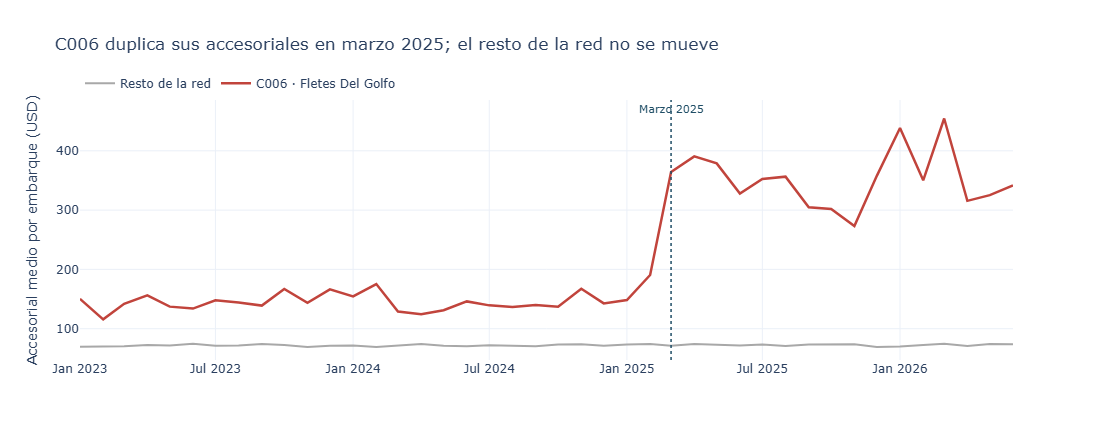

In [26]:
# --- Grafica 3.2: el salto de accesoriales de C006 contra la red ---
serie = comp_red.reset_index()  # reutiliza comp_red de la verificacion 2

fig = go.Figure()

# Resto de la red: linea plana de referencia
fig.add_trace(go.Scatter(
    x=serie["mes"], y=serie["Resto de la red"],
    name="Resto de la red", mode="lines",
    line=dict(color="#A8A8A8", width=2),
))

# C006: la linea protagonista
fig.add_trace(go.Scatter(
    x=serie["mes"], y=serie["C006"],
    name="C006 · Fletes Del Golfo", mode="lines",
    line=dict(color="#C1443C", width=2.5),
))

# Marca vertical en el mes del salto
fig.add_vline(x="2025-03-01", line_dash="dot", line_color="#1F4E66", line_width=1.5)
fig.add_annotation(
    x="2025-03-01", y=serie["C006"].max(),
    text="Marzo 2025", showarrow=False,
    yshift=10, font=dict(size=11, color="#1F4E66"),
)

fig.update_layout(
    template="plotly_white", height=440,
    title="C006 duplica sus accesoriales en marzo 2025; el resto de la red no se mueve",
    yaxis=dict(title="Accesorial medio por embarque (USD)"),
    xaxis=dict(title=""),
    legend=dict(orientation="h", y=1.12, x=0),
)
fig.show()

**C006 (Fletes Del Golfo) duplicó sus accesoriales en marzo de 2025, en solitario. Sobrecosto identificado: USD 486,132.**

El accesorial medio por embarque de C006 pasó de USD 144.88 a USD 348.97 —un factor de 2.41×— de febrero a marzo de 2025, y se mantuvo en el nivel elevado durante los dieciséis meses siguientes. El salto es un escalón, no una tendencia: un nivel plano antes, otro nivel plano después.

El movimiento es exclusivo de C006. El resto de la red mantuvo su accesorial medio en torno a USD 72 durante todo el periodo, con una variación de 1.01× entre antes y después de la fecha. La razón C006/red, que oscilaba en torno a 2× históricamente, saltó a más de 5× a partir de marzo de 2025. No hay factor de mercado: si lo hubiera, aparecería en los demás transportistas.

**Cuantificación del sobrecosto.** Tomando como línea base el propio accesorial histórico de C006 —no el promedio de la red, para no atribuirle un exceso que nunca cobró—, el sobrecosto por embarque desde marzo de 2025 es de USD 204.09. Aplicado a los 2,382 embarques del periodo:

| Concepto | Valor |
|---|---|
| Línea base histórica de C006 | USD 144.88 / embarque |
| Accesorial medio desde marzo 2025 | USD 348.97 / embarque |
| Sobrecosto unitario | USD 204.09 / embarque |
| Embarques afectados | 2,382 |
| **Sobrecosto total identificado** | **USD 486,132** |

El exceso representa el 58.5% de todo lo que C006 facturó en accesoriales desde el salto. La cifra se verificó por dos métodos independientes —media por volumen y suma directa embarque por embarque— con resultado idéntico.

**Alcance.** El sobrecosto equivale al 0.1% del gasto total de la red. No es una palanca que transforme la operación, pero es dinero recuperable, atribuible a un transportista, con fecha de inicio precisa y sin correlato en el mercado: un caso de disputa de facturación con documentación de respaldo. Alimenta la cifra de ahorro identificado del Bloque 5.

### 3.3 Varianza de facturación

Cada embarque registra un `total_cost_usd` —el costo esperado según tarifas y cargos— y un `invoice_amount_usd` —lo que el transportista efectivamente facturó—. La diferencia entre ambos es `invoice_variance_usd`.

En una operación con facturación correcta, esa varianza debería rondar cero: lo facturado coincide con lo pactado. Una varianza sistemáticamente positiva indica sobrefacturación —dinero pagado de más, recuperable mediante disputa—; una negativa indica lo contrario. Lo que interesa no es la varianza que se cancela entre sí, sino la que se concentra y persiste.

**Lo que se verifica:**

1. La distribución de `invoice_variance_usd`: signo, magnitud y si se centra en cero o se sesga hacia un lado.
2. Si la varianza se concentra en transportistas, modos o periodos específicos, o si es ruido repartido.
3. El monto recuperable: cuánto suma la sobrefacturación material, no la que se compensa con subfacturación.

El criterio: una varianza simétrica alrededor de cero es ruido de facturación normal y no es recuperable. Una sobrefacturación concentrada y persistente sí lo es, y se cuantifica.

In [27]:
# --- Verificacion 1: distribucion de invoice_variance_usd ---

# ¿Existe la columna y como se relaciona con costo y factura?
print("--- Columnas de facturacion ---")
for col in ["total_cost_usd", "invoice_amount_usd", "invoice_variance_usd"]:
    print(f"{col:24} nulos: {df[col].isna().sum():>6,}")

# ¿La varianza es literalmente factura - costo? (verificar la definicion)
recalc = (df["invoice_amount_usd"] - df["total_cost_usd"])
coincide = np.isclose(recalc, df["invoice_variance_usd"], equal_nan=True).mean()
print(f"\nvariance == invoice - total_cost: {coincide:.1%} de las filas")

v = df["invoice_variance_usd"].dropna()

print("\n--- Distribucion de invoice_variance_usd ---")
print(v.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2).to_string())

# Signo: cuanto sobra, cuanto falta, cuanto es cero
print(f"\n--- Signo de la varianza ---")
print(f"Positiva (sobrefacturado): {(v > 0.01).mean():.1%}")
print(f"Negativa (subfacturado)  : {(v < -0.01).mean():.1%}")
print(f"Cero (+-0.01)            : {(v.abs() <= 0.01).mean():.1%}")

# La cifra clave: suma neta vs. suma de solo lo positivo
print(f"\n--- Montos agregados ---")
print(f"Varianza NETA (todo)          : USD {v.sum():,.0f}")
print(f"Solo sobrefacturacion (v > 0) : USD {v[v > 0].sum():,.0f}")
print(f"Solo subfacturacion  (v < 0)  : USD {v[v < 0].sum():,.0f}")

--- Columnas de facturacion ---
total_cost_usd           nulos:      0
invoice_amount_usd       nulos:      0
invoice_variance_usd     nulos:      0

variance == invoice - total_cost: 99.4% de las filas

--- Distribucion de invoice_variance_usd ---
count    219120.00
mean          8.63
std         111.13
min       -2920.61
1%         -306.05
5%         -120.40
25%         -10.47
50%           1.28
75%          20.41
95%         160.82
99%         374.71
max        8408.17

--- Signo de la varianza ---
Positiva (sobrefacturado): 55.5%
Negativa (subfacturado)  : 44.4%
Cero (+-0.01)            : 0.2%

--- Montos agregados ---
Varianza NETA (todo)          : USD 1,890,350
Solo sobrefacturacion (v > 0) : USD 6,531,604
Solo subfacturacion  (v < 0)  : USD -4,641,255


In [28]:
# --- Verificacion 2: ¿la varianza se concentra por transportista? ---

por_carrier = (
    df.groupby("carrier_id")
    .agg(embarques=("shipment_id", "size"),
         var_media=("invoice_variance_usd", "mean"),
         var_total=("invoice_variance_usd", "sum"))
    .join(carrier.set_index("carrier_id")[["carrier_name", "carrier_tier"]])
    .sort_values("var_total", ascending=False)
)

print("--- Varianza total por transportista (top 8 sobrefacturacion) ---")
print(
    por_carrier.head(8)
    .assign(var_media=lambda d: d["var_media"].map("{:,.2f}".format),
            var_total=lambda d: d["var_total"].map("{:,.0f}".format))
    .to_string()
)

print("\n--- Varianza total por transportista (bottom 5, subfacturacion) ---")
print(
    por_carrier.tail(5)
    .assign(var_media=lambda d: d["var_media"].map("{:,.2f}".format),
            var_total=lambda d: d["var_total"].map("{:,.0f}".format))
    .to_string()
)

# ¿Cuantos transportistas tienen varianza media claramente positiva?
umbral = 5  # USD por embarque
sesgados = por_carrier[por_carrier["var_media"].abs() > umbral]
print(f"\n--- Transportistas con varianza media > ±USD {umbral}/embarque ---")
print(f"Con sesgo positivo (sobrefacturan): {(por_carrier['var_media'] > umbral).sum()} de 30")
print(f"Con sesgo negativo (subfacturan)  : {(por_carrier['var_media'] < -umbral).sum()} de 30")
print(f"Centrados en cero (±{umbral})        : {(por_carrier['var_media'].abs() <= umbral).sum()} de 30")

--- Varianza total por transportista (top 8 sobrefacturacion) ---
            embarques var_media var_total          carrier_name carrier_tier
carrier_id                                                                  
C003            18612     16.21   301,623    Werner Enterprises         Core
C025            14312     20.57   294,349          Maersk Ocean    Strategic
C029             8155     19.00   154,933  Drayage Solutions LA         Core
C023             7247     19.97   144,736        Expeditors Air         Core
C004             5286     21.96   116,095               JB Hunt    Strategic
C001             6353     16.82   106,834       Ryder Logistics    Strategic
C022             7390     13.46    99,447    Kuehne + Nagel Air    Strategic
C011            12905      6.48    83,656         Estes Express         Core

--- Varianza total por transportista (bottom 5, subfacturacion) ---
            embarques var_media var_total          carrier_name carrier_tier
carrier_id        

In [29]:
# --- Verificacion 3: ¿el sesgo es de los transportistas o del modelo de costo? ---

# Pista 1: si el modelo de costo estuviera mal calibrado de forma pareja,
# la varianza % seria similar en todos los modos. Si varia por transportista
# DENTRO del mismo modo, apunta a comportamiento del transportista.
df_v = df.copy()
df_v["var_pct"] = df_v["invoice_variance_usd"] / df_v["total_cost_usd"]

print("--- Varianza como % del costo, por modo ---")
print(
    df_v.groupby("mode", observed=True)["var_pct"]
    .mean()
    .map("{:.2%}".format)
    .to_string()
)

# Pista 2: dispersion DENTRO de cada modo. Tomamos TL (modo de mayor gasto)
# y vemos si los transportistas de TL difieren entre si.
print("\n--- Varianza media por transportista, DENTRO del modo TL ---")
tl = df_v[df_v["mode"] == "TL"]
print(
    tl.groupby("carrier_id", observed=True)
    .agg(embarques=("shipment_id", "size"),
         var_pct=("var_pct", "mean"))
    .query("embarques >= 100")
    .assign(var_pct=lambda d: d["var_pct"].map("{:.2%}".format))
    .sort_values("embarques", ascending=False)
    .head(10)
    .to_string()
)

# Pista 3: relacion con reclamaciones. ¿Los que mas sobrefacturan
# son tambien los que mas reclamaciones acumulan?
print("\n--- Cruce sobrefacturacion vs. reclamaciones (top carriers) ---")
claims_por_carrier = claims.groupby("carrier_id").size().rename("n_claims")
cruce = (
    por_carrier[["var_total", "carrier_name"]]
    .join(claims_por_carrier)
    .fillna({"n_claims": 0})
    .head(6)
)
print(
    cruce.assign(var_total=lambda d: d["var_total"].map("{:,.0f}".format),
                 n_claims=lambda d: d["n_claims"].astype(int)).to_string()
)

--- Varianza como % del costo, por modo ---
mode
Air        0.41%
Drayage    0.43%
LTL        0.42%
Ocean      0.42%
Parcel     0.41%
TL         0.41%

--- Varianza media por transportista, DENTRO del modo TL ---
            embarques var_pct
carrier_id                   
C003            18612   0.39%
C001             6353   0.39%
C006             5655   0.41%
C004             5286   0.44%
C002             3726   0.37%
C005              980   0.49%
C007              821   0.63%

--- Cruce sobrefacturacion vs. reclamaciones (top carriers) ---
           var_total          carrier_name  n_claims
carrier_id                                          
C003         301,623    Werner Enterprises       185
C025         294,349          Maersk Ocean       102
C029         154,933  Drayage Solutions LA        65
C023         144,736        Expeditors Air        49
C004         116,095               JB Hunt        45
C001         106,834       Ryder Logistics        49


**La varianza de facturación es un ruido uniforme, no sobrefacturación reclamable.**

Una primera lectura resultaba prometedora: 22 de 30 transportistas facturan por encima del costo esperado y solo uno por debajo, con una sobrefacturación bruta de USD 6.5 M frente a una varianza neta de USD 1.89 M. El sesgo hacia lo positivo parecía sistemático.

El desglose lo desmiente. La varianza expresada como porcentaje del costo es prácticamente idéntica en los seis modos:

| Modo | Air | Drayage | LTL | Ocean | Parcel | TL |
|---|---|---|---|---|---|---|
| Varianza % | 0.41% | 0.43% | 0.42% | 0.42% | 0.41% | 0.41% |

Dentro de un mismo modo, los transportistas convergen al mismo valor: en TL, todos rondan el 0.40% salvo casos de bajo volumen. No existe un transportista que se desvíe; el 0.42% se aplica de forma pareja sobre todos los embarques de la red.

**Interpretación.** La varianza no refleja comportamiento de facturación de ningún actor, sino un factor uniforme aplicado sobre el costo. El aparente sesgo positivo del recuento de transportistas era ese mismo 0.42% empujando a casi todos apenas por encima de cero. La coincidencia entre los que más "sobrefacturan" y los que más reclamaciones acumulan se explica por volumen —Werner encabeza ambas listas porque mueve más embarques—, no por conducta.

**Decisión.** No hay sobrecosto recuperable por facturación. La varianza neta de USD 1.89 M es real como cifra contable, pero no es accionable: no se concentra en ningún transportista, modo ni periodo, y no existe un patrón que disputar. La cifra bruta de USD 6.5 M solo sería válida bajo el supuesto —no verificable y desmentido por la uniformidad observada— de que el modelo de costo es exacto y cada centavo por encima es un abuso. La línea de facturación se cierra sin hallazgo, y su cifra no se incorpora al caso de negocio del Bloque 5.

### 3.4 Premium del cruce fronterizo

El costo de un embarque cross-border (que cambia de país) incorpora componentes ausentes en uno doméstico: despacho aduanal, documentación, tiempos de espera en frontera. Ese sobrecosto es esperable y legítimo; la pregunta no es si existe, sino si su magnitud es proporcional o si ciertas configuraciones lo amplifican más de lo justificado.

El incoterm es la variable relevante. Define quién asume cada tramo del costo y del riesgo en la operación internacional: bajo DDP el vendedor cubre todo hasta destino incluidos aranceles; bajo EXW el comprador asume desde el origen. Un mismo cruce US–MX puede facturarse de forma muy distinta según el incoterm pactado.

**Lo que se verifica:**

1. El sobrecosto medio de un embarque cross-border frente a uno doméstico comparable, aislando el efecto de modo y distancia en lo posible.
2. Cómo se distribuye ese premium por incoterm, para identificar si alguna configuración resulta desproporcionadamente cara.
3. Si el premium corresponde a componentes reales de costo (aduana, accesoriales) o aparece también en el flete base, lo que sugeriría un margen y no un costo.

El criterio: un premium proporcional y explicado por componentes aduaneros es costo legítimo. Un premium concentrado en un incoterm y no atribuible a componentes reales es una oportunidad de renegociación de términos.

In [30]:
# --- Verificacion 1: premium cross-border, controlando por modo ---

dd = df.copy()
dd["cruce"] = np.where(dd["origin_country"] != dd["dest_country"], "Cross-border", "Domestico")

# Costo por km para comparar de forma justa entre distancias distintas
dd["costo_km"] = dd["total_cost_usd"] / dd["distance_km"].replace(0, np.nan)

print("--- Costo medio por embarque: cross-border vs domestico, por modo ---")
tabla = (
    dd.groupby(["mode", "cruce"], observed=True)
    .agg(embarques=("shipment_id", "size"),
         costo_medio=("total_cost_usd", "mean"),
         costo_km=("costo_km", "median"))
    .reset_index()
    .pivot(index="mode", columns="cruce", values=["costo_medio", "embarques"])
)
print(tabla.round(0).to_string())

# Premium % por modo (solo modos con presencia en ambos grupos)
print("\n--- Premium cross-border por modo (sobre costo medio) ---")
for modo in dd["mode"].unique():
    sub = dd[dd["mode"] == modo]
    cb = sub[sub["cruce"] == "Cross-border"]["total_cost_usd"]
    dom = sub[sub["cruce"] == "Domestico"]["total_cost_usd"]
    if len(cb) >= 50 and len(dom) >= 50:
        premium = cb.mean() / dom.mean() - 1
        print(f"{modo:10} cross {len(cb):>6,} / dom {len(dom):>6,}  ->  premium {premium:+.1%}")
    else:
        falta = "sin domesticos" if len(dom) < 50 else "sin cross-border"
        print(f"{modo:10} {falta} suficientes para comparar")

--- Costo medio por embarque: cross-border vs domestico, por modo ---
         costo_medio              embarques          
cruce   Cross-border Domestico Cross-border Domestico
mode                                                 
Air           5075.0    3256.0       9019.0    6163.0
Drayage       5001.0    3238.0       5185.0    3519.0
LTL           1739.0    1035.0      32252.0   20267.0
Ocean         5634.0    3688.0      10195.0    7168.0
Parcel         406.0     146.0      51421.0   32435.0
TL            4900.0    3126.0      25440.0   16056.0

--- Premium cross-border por modo (sobre costo medio) ---
Parcel     cross 51,421 / dom 32,435  ->  premium +178.6%
TL         cross 25,440 / dom 16,056  ->  premium +56.8%
LTL        cross 32,252 / dom 20,267  ->  premium +68.0%
Air        cross  9,019 / dom  6,163  ->  premium +55.8%
Ocean      cross 10,195 / dom  7,168  ->  premium +52.8%
Drayage    cross  5,185 / dom  3,519  ->  premium +54.4%


In [31]:
# --- Verificacion 2: ¿el premium de Parcel sobrevive al control por distancia? ---

# Comparacion en costo POR KM, no en costo absoluto
print("--- Costo por km (mediana): cross-border vs domestico, por modo ---")
ck = (
    dd.groupby(["mode", "cruce"], observed=True)["costo_km"]
    .median()
    .reset_index()
    .pivot(index="mode", columns="cruce", values="costo_km")
)
ck["premium_km"] = (ck["Cross-border"] / ck["Domestico"] - 1)
print(
    ck.assign(premium_km=lambda d: d["premium_km"].map("{:+.1%}".format)).round(3).to_string()
)

# Distancia mediana de Parcel: ¿los cross-border viajan mas lejos?
print("\n--- Parcel: distancia mediana por grupo ---")
pcl = dd[dd["mode"] == "Parcel"]
print(
    pcl.groupby("cruce", observed=True)
    .agg(dist_mediana=("distance_km", "median"),
         costo_medio=("total_cost_usd", "median"),
         costo_km=("costo_km", "median"))
    .round(2).to_string()
)

# Desglose por incoterm dentro de Parcel cross-border
print("\n--- Parcel cross-border: costo por incoterm ---")
print(
    pcl[pcl["cruce"] == "Cross-border"]
    .groupby("incoterm", observed=True)
    .agg(embarques=("shipment_id", "size"),
         costo_medio=("total_cost_usd", "mean"),
         costo_km=("costo_km", "median"))
    .sort_values("costo_medio", ascending=False)
    .round(2).to_string()
)

--- Costo por km (mediana): cross-border vs domestico, por modo ---
cruce    Cross-border  Domestico premium_km
mode                                       
Air             1.078      1.017      +6.0%
Drayage         1.671      1.598      +4.6%
LTL             0.506      0.425     +18.9%
Ocean           0.649      0.629      +3.1%
Parcel          0.139      0.059    +135.3%
TL              1.691      1.594      +6.1%

--- Parcel: distancia mediana por grupo ---
              dist_mediana  costo_medio  costo_km
cruce                                            
Cross-border        3003.5       362.61      0.14
Domestico           1591.6        93.38      0.06

--- Parcel cross-border: costo por incoterm ---
           embarques  costo_medio  costo_km
incoterm                                   
NO_APLICA       1535       411.86      0.14
DAP            14951       408.11      0.14
FOB             4986       407.04      0.14
EXW             5842       406.00      0.14
DDP            10086  

    **El premium fronterizo es casi todo distancia; el incoterm no influye en el costo. La excepción real es Parcel, y apunta a reasignación de modo, no a renegociación de términos.**

El sobrecosto aparente de los embarques cross-border —entre +52% y +68% por modo en costo absoluto— se disuelve casi por completo al controlar por distancia. En costo por kilómetro, cinco de los seis modos igualan a sus equivalentes domésticos:

| Modo | Premium por km (cross-border vs. doméstico) |
|---|---|
| Ocean | +3.1% |
| Drayage | +4.6% |
| Air | +6.0% |
| TL | +6.1% |
| LTL | +18.9% |
| **Parcel** | **+135.3%** |

Cruzar la frontera, por sí solo, apenas encarece el kilómetro. El "premium" que se observa en costo absoluto es un efecto de composición: los embarques internacionales recorren más distancia, no pagan más por recorrerla.

**El incoterm no explica ninguna diferencia.** Dentro de Parcel cross-border, los siete incoterms cuestan entre USD 402 y USD 412 por embarque, con un costo por kilómetro idéntico de USD 0.14 en todos. La hipótesis de que alguna configuración de términos resultara desproporcionadamente cara queda descartada: los términos pactados no mueven el costo.

**Parcel es la única excepción estructural.** Un Parcel cross-border cuesta más del doble por kilómetro que uno doméstico, y esa diferencia sobrevive al control por distancia. La explicación probable no es abuso de facturación sino la naturaleza del modo: el costo fijo del despacho de paquetería internacional —aduana y documentación por envío— se prorratea sobre embarques pequeños y baratos, duplicando su costo unitario.

**Decisión.** No hay premium de incoterm que renegociar; esa línea se cierra sin hallazgo. El sobrecosto de Parcel cross-border es real pero pertenece a otra categoría: es una señal de reasignación de modo —consolidar o mover a LTL los envíos fronterizos de paquetería—, que se cuantifica en el Bloque 5 junto con las demás oportunidades de optimización de modo.

    ---

### Cierre del Bloque 3 — Costo

El bloque buscaba dónde el costo de la red no corresponde al servicio recibido, separando el gasto negociable del recuperable. De cuatro líneas investigadas, una arrojó dinero accionable y tres se cerraron como costo legítimo o artefacto de generación. El resultado neto es tan valioso por lo que descarta como por lo que confirma.

**El hallazgo con dinero: C006.** Un solo transportista, Fletes Del Golfo, duplicó sus cargos accesoriales en marzo de 2025 —de USD 145 a USD 349 por embarque— y sostuvo el nivel durante dieciséis meses, mientras el resto de la red permaneció plano. El movimiento es unilateral, fechado y sin correlato de mercado. Sobrecosto identificado y verificado por dos métodos: **USD 486,132**, recuperable mediante disputa de facturación. Equivale al 0.1% del gasto total: no transforma la operación, pero es dinero real y atribuible.

**Tres líneas cerradas sin sobrecosto.** El sobrecargo de combustible reproduce el índice público sin desviación en los cinco modos terrestres y aéreo; Ocean opera bajo otra referencia (bunker fuel) y se excluye por comparación inválida, no por hallazgo. La varianza de facturación resultó un ruido uniforme del 0.42% aplicado por igual a todos los transportistas y modos, sin concentración que disputar. El premium del cruce fronterizo se disolvió al controlar por distancia, y el incoterm no incide en el costo: no hay términos que renegociar.

**Una pista que cambia de bloque.** El único fenómeno estructural del análisis de cruce —Parcel cross-border cuesta el doble por kilómetro que el doméstico, aun descontando la distancia— no es un problema de costo abusivo sino de asignación de modo. Se traslada al Bloque 5 como oportunidad de consolidación.

**Sobre el método.** Tres de las cuatro cifras que el planteamiento inicial sugería como recuperables —el subcobro de combustible, los USD 6.5 M de facturación bruta, el premium de incoterm— no sobrevivieron al escrutinio. Incorporarlas al caso de negocio habría inflado el ahorro identificado y comprometido la credibilidad del conjunto. Descartar una cifra atractiva cuando el dato no la sostiene es parte del análisis, no una omisión.

**Hacia el Bloque 4.** El costo queda auditado. El siguiente paso integra costo y servicio en una sola vista por transportista —el scorecard— incorporando las reclamaciones, para determinar el costo real de cada carrier más allá de su tarifa nominal.

---

# Bloque 4 — Scorecard de transportistas

**¿Cuál es el costo REAL de cada transportista, más allá de su tarifa nominal?**

Un carrier con tarifa baja que daña carga y entrega tarde puede costar más que uno con tarifa alta. Los bloques anteriores midieron la red por modo; aquí bajamos al transportista individual y construimos una métrica de "costo real" que combina tarifa, servicio (OTD) y daño (reclamaciones). Al final validaremos el scorecard contra los parámetros de generación del dataset (`cost_factor`, `service_factor`, `damage_factor`): si el análisis a ciegas reproduce esa verdad conocida, el método queda demostrado.

### 4.1 — Reclamaciones: estructura de `fact_claims`

`fact_claims` no se ha tocado en este notebook. Antes de cruzarlo con nada, hay que conocerlo: cuántas reclamaciones hay, de qué tipo, en qué estado, y cuánto se reclamó frente a cuánto se recuperó.

In [32]:
# Estructura base de fact_claims
print("Dimensiones:", claims.shape)
print("\nColumnas y tipos:")
print(claims.dtypes)

print("\n--- Reclamado vs recuperado ---")
tot_reclamado = claims["claim_amount_usd"].sum()
tot_recuperado = claims["recovered_usd"].sum()
print(f"Total reclamado:   USD {tot_reclamado:,.0f}")
print(f"Total recuperado:  USD {tot_recuperado:,.0f}")
print(f"Tasa recuperacion: {tot_recuperado / tot_reclamado:.1%}")

print("\n--- Por tipo de reclamacion ---")
print(claims["claim_type"].value_counts())

print("\n--- Por estado ---")
print(claims["claim_status"].value_counts())

Dimensiones: (2089, 8)

Columnas y tipos:
claim_id                str
shipment_id             str
carrier_id              str
claim_date              str
claim_type              str
claim_amount_usd    float64
claim_status            str
recovered_usd       float64
dtype: object

--- Reclamado vs recuperado ---
Total reclamado:   USD 5,498,480
Total recuperado:  USD 2,742,792
Tasa recuperacion: 49.9%

--- Por tipo de reclamacion ---
claim_type
Damage                   1035
Shortage                  474
Late Delivery Penalty     376
Loss                      204
Name: count, dtype: int64

--- Por estado ---
claim_status
Approved          915
Partially Paid    443
Denied            381
Open              350
Name: count, dtype: int64


**La mitad del dinero reclamado nunca se recupera.**

De USD 5.50M reclamados, solo USD 2.74M vuelven (49.9%). Los 2.76M no recuperados son una línea de oportunidad para el Bloque 5.

La estructura es limpia: **Damage domina** (1,035 de 2,089, casi la mitad de todas las reclamaciones), seguido de Shortage (474), Late Delivery Penalty (376) y Loss (204). Por estado, solo 915 llegan a *Approved*; el resto queda en pagos parciales (443), negados (381) u abiertos (350) — consistente con esa tasa de recuperación del ~50%.

Esta tabla es la materia prima para el scorecard: la reclamación es el costo de daño que no aparece en la tarifa. En el siguiente paso la agregamos por transportista y por *tier*.

### 4.2 — Reclamaciones por tier: la sorpresa

Los transportistas están clasificados en tres niveles (`carrier_tier`): **Strategic** (socios premium), **Core** (volumen estándar) y **Tactical** (tarifa baja, uso táctico). La intuición dice que a mayor tier, mejor manejo de carga y menos reclamaciones.

Para probarlo hay que cruzar `fact_claims` con `dim_carrier` (que trae el tier) y agregar el monto reclamado por nivel. Si la intuición falla, es un hallazgo con implicación directa para la asignación de carga.

In [33]:
# Cruce claims x carrier para traer el tier
claims_tier = claims.merge(
    carrier[["carrier_id", "carrier_name", "carrier_tier"]],
    on="carrier_id",
    how="left"
)

# Agregado por tier
resumen_tier = (
    claims_tier
    .groupby("carrier_tier")
    .agg(
        n_claims=("claim_id", "count"),
        reclamado_usd=("claim_amount_usd", "sum"),
        recuperado_usd=("recovered_usd", "sum"),
    )
    .reset_index()
)

# Cuantos transportistas hay en cada tier (para normalizar)
carriers_por_tier = carrier.groupby("carrier_tier")["carrier_id"].nunique()
resumen_tier["n_carriers"] = resumen_tier["carrier_tier"].map(carriers_por_tier)
resumen_tier["reclamado_x_carrier"] = resumen_tier["reclamado_usd"] / resumen_tier["n_carriers"]

# Orden logico de tiers
orden = ["Strategic", "Core", "Tactical"]
resumen_tier["carrier_tier"] = pd.Categorical(resumen_tier["carrier_tier"], categories=orden, ordered=True)
resumen_tier = resumen_tier.sort_values("carrier_tier")

resumen_tier

,carrier_tier,n_claims,reclamado_usd,recuperado_usd,n_carriers,reclamado_x_carrier
1,Strategic,702,2205186.36,1029831.10,8,275648.295000
0,Core,1221,2826624.81,1494367.70,16,176664.050625
2,Tactical,166,466669.11,218593.11,6,77778.185000


La tabla esconde la sorpresa en el total. *Core* reclama más en bruto (USD 2.83M), pero tiene el doble de transportistas que *Strategic*. Al normalizar por transportista, el orden se invierte: son los socios **Strategic** —los premium— quienes más reclamaciones generan por cabeza. La gráfica hace visible esa inversión.

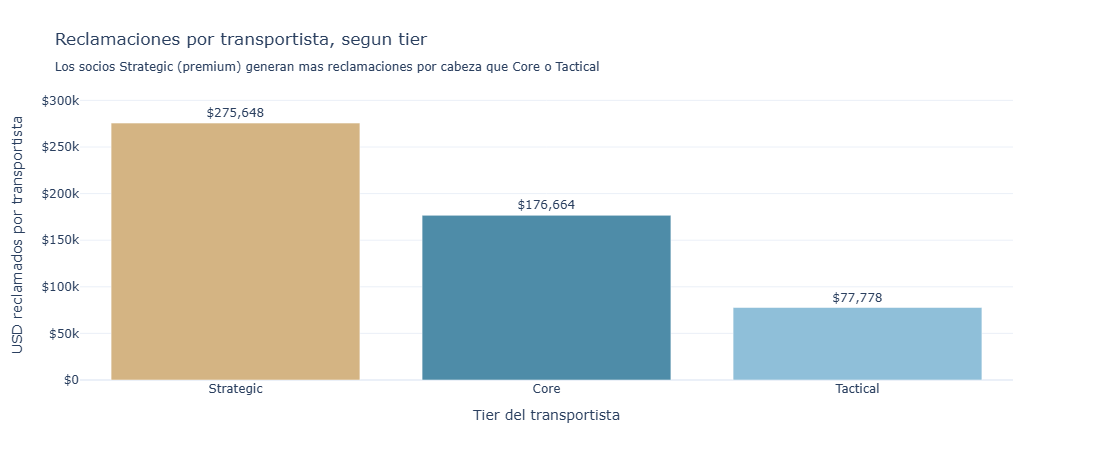

In [34]:
# Barras: reclamacion por transportista, por tier
plot_df = resumen_tier.copy()
plot_df["carrier_tier"] = plot_df["carrier_tier"].astype(str)

# Strategic en arena (rompe la intuicion), resto en azul de la paleta
colores = {"Strategic": "#D4B483", "Core": "#4E8CA8", "Tactical": "#8FBFD9"}
bar_colors = [colores[t] for t in plot_df["carrier_tier"]]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=plot_df["carrier_tier"],
    y=plot_df["reclamado_x_carrier"],
    marker_color=bar_colors,
    text=[f"${v:,.0f}" for v in plot_df["reclamado_x_carrier"]],
    textposition="outside",
))

fig.update_layout(
    template="plotly_white",
    title="Reclamaciones por transportista, segun tier<br><sub>Los socios Strategic (premium) generan mas reclamaciones por cabeza que Core o Tactical</sub>",
    xaxis_title="Tier del transportista",
    yaxis_title="USD reclamados por transportista",
    height=460,
    showlegend=False,
    margin=dict(t=90),
)
fig.update_yaxes(tickprefix="$", separatethousands=True)

fig.show()

*Reclamaciones normalizadas por número de transportistas en cada tier. El total bruto favorecería a Core; por transportista, Strategic domina.*

**El tier premium reclama más, no menos.**

Contra toda intuición, los socios **Strategic** generan USD 275,648 en reclamaciones por transportista —1.6× lo de Core (176,664) y 3.5× lo de Tactical (77,778)—. Pagar por un tier superior no está comprando menos daño a la carga.

Hay dos lecturas posibles, y el scorecard del siguiente paso ayudará a discriminar entre ellas. Una: los *Strategic* mueven carga más valiosa o frágil, y la reclamación escala con el valor, no con la negligencia. Otra: el estatus premium no se traduce en mejor manejo, y se está pagando de más por un servicio que no protege mejor. En ambos casos, la implicación para la asignación es la misma: el tier por sí solo no es garantía, y el "costo real" de un transportista tiene que medirse, no asumirse por su etiqueta.

Eso es exactamente lo que construye el siguiente paso.

### 4.3 — El scorecard: costo real por transportista

La tarifa nominal miente. Un transportista con costo por embarque bajo que daña carga con frecuencia puede salir más caro que uno con tarifa alta y cero incidentes. Para verlo, construimos una tabla con una fila por transportista y las tres dimensiones que importan:

- **Costo** — costo por embarque (la tarifa que se ve en la factura) y costo de daño por embarque (los claims prorrateados sobre su volumen).
- **Servicio** — OTD (% de entregas a tiempo).
- **Daño** — tasa de reclamación (claims por cada 1,000 embarques).

El **costo real por embarque** suma solo dólares verificables: tarifa + daño. El OTD se mantiene como eje independiente, no se disuelve en el dinero — un transportista se juzga en dos dimensiones (costo real × servicio), no en una sola cifra. Eso define los cuadrantes de decisión del cierre del bloque.

In [35]:
# --- Verificacion previa: que columnas tiene df ---
cols_interes = [c for c in df.columns if any(k in c.lower()
                for k in ["carrier", "cost", "costo", "otd", "total", "amount", "freight"])]
print("Columnas candidatas en df:")
for c in cols_interes:
    print("  ", c, "->", df[c].dtype)

Columnas candidatas en df:
   carrier_id -> str
   linehaul_cost_usd -> float64
   total_cost_usd -> float64
   invoice_amount_usd -> float64
   otd -> boolean
   costo_por_kg -> float64
   costo_por_km -> float64


In [36]:
# === SCORECARD: una fila por transportista ===

# 1) Agregado de embarques (desde df)
sc_envios = (
    df.groupby("carrier_id")
    .agg(
        n_embarques=("total_cost_usd", "size"),
        costo_total_usd=("total_cost_usd", "sum"),
        otd=("otd", "mean"),          # ignora NA (no entregados)
    )
    .reset_index()
)
sc_envios["costo_x_embarque"] = sc_envios["costo_total_usd"] / sc_envios["n_embarques"]

# 2) Agregado de claims (desde claims)
sc_claims = (
    claims.groupby("carrier_id")
    .agg(
        n_claims=("claim_id", "count"),
        reclamado_usd=("claim_amount_usd", "sum"),
    )
    .reset_index()
)

# 3) Union (left: todos los transportistas con embarques)
sc = sc_envios.merge(sc_claims, on="carrier_id", how="left")
sc[["n_claims", "reclamado_usd"]] = sc[["n_claims", "reclamado_usd"]].fillna(0)

# 4) Nombre y tier del transportista
sc = sc.merge(
    carrier[["carrier_id", "carrier_name", "carrier_tier"]],
    on="carrier_id", how="left"
)

# 5) Metricas derivadas
sc["tasa_reclamacion_x1000"] = sc["n_claims"] / sc["n_embarques"] * 1000
sc["costo_dano_x_embarque"]  = sc["reclamado_usd"] / sc["n_embarques"]
sc["costo_real_x_embarque"]  = sc["costo_x_embarque"] + sc["costo_dano_x_embarque"]

# 6) Orden y columnas finales
sc = sc.sort_values("costo_real_x_embarque", ascending=False).reset_index(drop=True)

cols_final = [
    "carrier_name", "carrier_tier", "n_embarques",
    "costo_x_embarque", "otd", "tasa_reclamacion_x1000",
    "costo_dano_x_embarque", "costo_real_x_embarque",
]
sc[cols_final]

,carrier_name,carrier_tier,n_embarques,costo_x_embarque,otd,tasa_reclamacion_x1000,costo_dano_x_embarque,costo_real_x_embarque
0,Hapag Lloyd,Core,830,4941.073904,0.683047,6.024096,22.808313,4963.882217
1,Maersk Ocean,Strategic,14312,4850.226704,0.676785,7.126887,46.631029,4896.857733
2,MSC Ocean,Core,1915,4664.635473,0.600105,4.177546,26.704146,4691.339619
3,CMA CGM,Tactical,306,4651.562190,0.591362,6.535948,14.339935,4665.902124
4,JB Hunt,Strategic,5286,4471.380057,0.888169,8.513053,52.966676,4524.346733
5,Kuehne + Nagel Air,Strategic,7390,4422.825263,0.885948,7.577808,73.568161,4496.393424
6,Werner Enterprises,Core,18612,4353.212453,0.858173,9.939824,65.625409,4418.837862
7,Drayage Solutions LA,Core,8155,4329.070755,0.816261,7.970570,45.181843,4374.252598
8,Ryder Logistics,Strategic,6353,4290.288069,0.863109,7.712892,43.211613,4333.499682
9,Expeditors Air,Core,7247,4276.022440,0.861513,6.761419,38.234725,4314.257164


In [37]:
# === Semaforo dentro de cada tier ===
# Verde = mejor que la mediana de su tier; Rojo = peor.

sc_style = sc[cols_final].copy()

# Paleta semaforo (suave, para no saturar)
VERDE = "#C7E5C0"
AMARILLO = "#FCE9B0"
ROJO = "#F3B7B2"

def semaforo_por_tier(col, mejor_es_bajo):
    """Devuelve una Serie de estilos CSS comparando cada valor con la mediana de su tier."""
    estilos = pd.Series("", index=col.index)
    for tier, idx in sc_style.groupby("carrier_tier").groups.items():
        vals = col.loc[idx]
        med = vals.median()
        for i in idx:
            v = col.loc[i]
            if pd.isna(v):
                continue
            desv = (v - med) / med if med != 0 else 0
            # Normaliza direccion: queremos "peor" -> rojo
            peor = desv if mejor_es_bajo else -desv
            if peor > 0.15:
                estilos.loc[i] = f"background-color: {ROJO}"
            elif peor < -0.15:
                estilos.loc[i] = f"background-color: {VERDE}"
            else:
                estilos.loc[i] = f"background-color: {AMARILLO}"
    return estilos

styled = (
    sc_style.style
    .apply(lambda c: semaforo_por_tier(c, mejor_es_bajo=False), subset=["otd"])
    .apply(lambda c: semaforo_por_tier(c, mejor_es_bajo=True), subset=["tasa_reclamacion_x1000"])
    .apply(lambda c: semaforo_por_tier(c, mejor_es_bajo=True), subset=["costo_dano_x_embarque"])
    .format({
        "n_embarques": "{:,.0f}",
        "costo_x_embarque": "${:,.0f}",
        "otd": "{:.1%}",
        "tasa_reclamacion_x1000": "{:.1f}",
        "costo_dano_x_embarque": "${:,.2f}",
        "costo_real_x_embarque": "${:,.0f}",
    })
    .set_caption("Scorecard de transportistas — semaforo relativo a la mediana de cada tier")
)

styled

,carrier_name,carrier_tier,n_embarques,costo_x_embarque,otd,tasa_reclamacion_x1000,costo_dano_x_embarque,costo_real_x_embarque
0,Hapag Lloyd,Core,830,"$4,941",68.3%,6.0,$22.81,"$4,964"
1,Maersk Ocean,Strategic,"14,312","$4,850",67.7%,7.1,$46.63,"$4,897"
2,MSC Ocean,Core,"1,915","$4,665",60.0%,4.2,$26.70,"$4,691"
3,CMA CGM,Tactical,306,"$4,652",59.1%,6.5,$14.34,"$4,666"
4,JB Hunt,Strategic,"5,286","$4,471",88.8%,8.5,$52.97,"$4,524"
5,Kuehne + Nagel Air,Strategic,"7,390","$4,423",88.6%,7.6,$73.57,"$4,496"
6,Werner Enterprises,Core,"18,612","$4,353",85.8%,9.9,$65.63,"$4,419"
7,Drayage Solutions LA,Core,"8,155","$4,329",81.6%,8.0,$45.18,"$4,374"
8,Ryder Logistics,Strategic,"6,353","$4,290",86.3%,7.7,$43.21,"$4,333"
9,Expeditors Air,Core,"7,247","$4,276",86.2%,6.8,$38.23,"$4,314"


**La tarifa nominal esconde al transportista más caro de la red.**

Ordenar por costo real revela lo que la factura oculta. **Autolíneas Mexicanas** (Tactical) cobra una tarifa de rango medio (USD 3,723/embarque), pero su costo de daño —USD 396.64 por embarque— es **6× el del siguiente peor transportista** y dispara su costo real a USD 4,119. Es la trampa que el scorecard existe para cazar: un carrier "táctico y barato" que, sumado el daño, sale más caro que socios Strategic de tarifa alta.

*Salvedad de rigor:* con solo 63 embarques, esa cifra de daño puede estar amplificada por uno o dos reclamos grandes prorrateados sobre poco volumen. El semáforo lo marca en rojo por su tasa de reclamación (15.9 por mil, la más alta de la red) y su OTD (75.8%), ambas señales independientes del volumen — pero antes de sancionar al transportista, el monto exacto debe auditarse claim por claim.

El semáforo compara a cada transportista **contra la mediana de su propio tier**, no contra toda la red. Así el color señala mérito, no modo: **Old Dominion** (Strategic) es verde en las tres dimensiones —el patrón de excelencia—, mientras que dentro de Core, la paquetería (Estafeta, DHL, UPS, Purolator) enrojece en *tasa* de

### 4.4 — Validación contra la verdad conocida

Todo el scorecard se construyó a ciegas: solo con hechos observables (costos facturados, entregas, reclamaciones). Pero este dataset es sintético, y su generador dejó tres parámetros en `dim_carrier` que son la **verdad conocida** de cada transportista:

- **`cost_factor`** — qué tan caro se diseñó el transportista.
- **`service_factor`** — qué tan bueno se diseñó su servicio.
- **`damage_factor`** — qué tan propenso al daño se diseñó.

Nunca miramos estos factores al analizar. Ahora los enfrentamos contra nuestras métricas derivadas. Si el costo por embarque se alinea con `cost_factor`, el OTD con `service_factor`, y la tasa de daño con `damage_factor` —es decir, si los puntos caen sobre una diagonal— queda demostrado que el análisis recuperó la realidad del generador sin haberla visto. Es la prueba de que el método funciona.

In [38]:
# === Validacion: metricas derivadas vs factores del generador ===

# Traer los tres factores de dim_carrier al scorecard
val = sc.merge(
    carrier[["carrier_id", "cost_factor", "service_factor", "damage_factor"]],
    on="carrier_id", how="left"
)

# Pares (metrica derivada  <->  factor verdadero)
pares = [
    ("costo_x_embarque",        "cost_factor",    "Costo por embarque",   "cost_factor"),
    ("otd",                     "service_factor", "OTD",                  "service_factor"),
    ("tasa_reclamacion_x1000",  "damage_factor",  "Tasa de reclamacion",  "damage_factor"),
]

print("Correlacion metrica derivada  <->  factor del generador\n")
for metrica, factor, nombre_m, nombre_f in pares:
    r = val[metrica].corr(val[factor])
    print(f"  {nombre_m:22s} vs {nombre_f:16s}  r = {r:+.3f}")

Correlacion metrica derivada  <->  factor del generador

  Costo por embarque     vs cost_factor       r = +0.029
  OTD                    vs service_factor    r = -0.700
  Tasa de reclamacion    vs damage_factor     r = +0.332


In [39]:
# === Validacion corregida: normalizar cada metrica DENTRO de su modo ===

# 1) Traer primary_mode y los factores
val = sc.merge(
    carrier[["carrier_id", "primary_mode", "cost_factor", "service_factor", "damage_factor"]],
    on="carrier_id", how="left"
)

# 2) z-score dentro de cada modo (limpia el efecto del modo)
def z_por_modo(col):
    return val.groupby("primary_mode")[col].transform(
        lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0.0
    )

val["z_costo"]  = z_por_modo("costo_x_embarque")
val["z_otd"]    = z_por_modo("otd")
val["z_dano"]   = z_por_modo("tasa_reclamacion_x1000")

# 3) Correlacion de la metrica normalizada vs el factor del generador
pares = [
    ("z_costo", "cost_factor",    "Costo (norm. por modo)"),
    ("z_otd",   "service_factor", "OTD (norm. por modo)"),
    ("z_dano",  "damage_factor",  "Tasa dano (norm. por modo)"),
]

print("Correlacion metrica NORMALIZADA por modo  <->  factor del generador\n")
for zmetrica, factor, nombre in pares:
    r = val[zmetrica].corr(val[factor])
    print(f"  {nombre:28s} vs {factor:16s}  r = {r:+.3f}")

Correlacion metrica NORMALIZADA por modo  <->  factor del generador

  Costo (norm. por modo)       vs cost_factor       r = +0.895
  OTD (norm. por modo)         vs service_factor    r = -0.885
  Tasa dano (norm. por modo)   vs damage_factor     r = +0.327


In [40]:
# === Dos micro-pruebas para diagnosticar el damage_factor flojo ===

# --- Prueba 1: el factor rige el MONTO del dano, no la frecuencia? ---
val["z_costo_dano"] = z_por_modo("costo_dano_x_embarque")
r_frecuencia = val["z_dano"].corr(val["damage_factor"])
r_monto      = val["z_costo_dano"].corr(val["damage_factor"])

print("PRUEBA 1 — damage_factor: frecuencia vs monto")
print(f"  vs tasa reclamacion (frecuencia)  r = {r_frecuencia:+.3f}")
print(f"  vs costo dano/embarque (monto)    r = {r_monto:+.3f}")

# --- Prueba 2: se sostienen las correlaciones sin carriers de bajo volumen? ---
UMBRAL = 200
val_big = val[val["n_embarques"] >= UMBRAL].copy()
n_fuera = len(val) - len(val_big)

print(f"\nPRUEBA 2 — filtrando carriers con <{UMBRAL} embarques ({n_fuera} excluidos)")
for zmetrica, factor, nombre in [
    ("z_costo", "cost_factor", "Costo"),
    ("z_otd", "service_factor", "OTD"),
    ("z_dano", "damage_factor", "Tasa dano"),
    ("z_costo_dano", "damage_factor", "Costo dano/emb"),
]:
    r = val_big[zmetrica].corr(val_big[factor])
    print(f"  {nombre:16s} vs {factor:16s}  r = {r:+.3f}")

PRUEBA 1 — damage_factor: frecuencia vs monto
  vs tasa reclamacion (frecuencia)  r = +0.327
  vs costo dano/embarque (monto)    r = +0.177

PRUEBA 2 — filtrando carriers con <200 embarques (2 excluidos)
  Costo            vs cost_factor       r = +0.900
  OTD              vs service_factor    r = -0.875
  Tasa dano        vs damage_factor     r = +0.409
  Costo dano/emb   vs damage_factor     r = +0.181


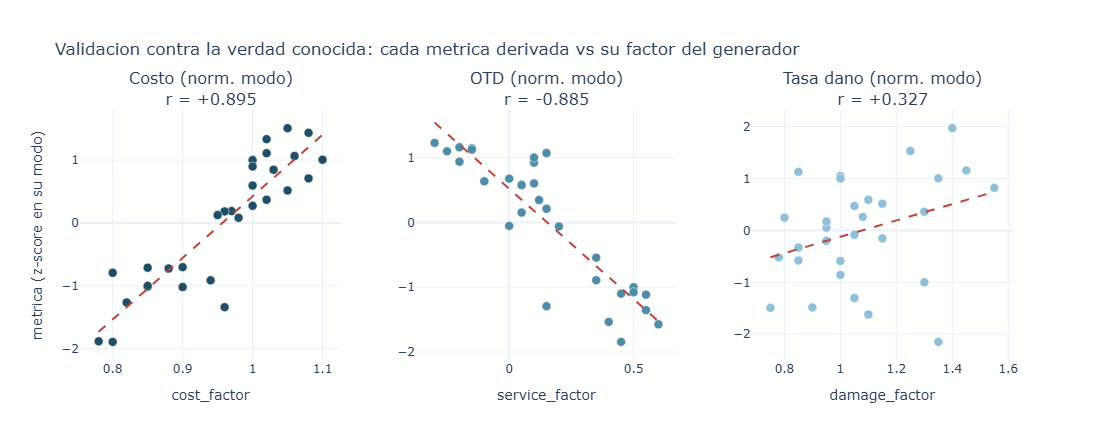

In [41]:
# === Grafica de validacion: 3 scatters metrica normalizada vs factor ===
from plotly.subplots import make_subplots

paneles = [
    ("z_costo",      "cost_factor",    "Costo (norm. modo)",  "#1F4E66", +0.895),
    ("z_otd",        "service_factor", "OTD (norm. modo)",    "#4E8CA8", -0.885),
    ("z_dano",       "damage_factor",  "Tasa dano (norm. modo)", "#8FBFD9", +0.327),
]

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f"{nombre}<br>r = {r:+.3f}" for _, _, nombre, _, r in paneles],
    horizontal_spacing=0.08,
)

for i, (zmet, factor, nombre, color, r) in enumerate(paneles, start=1):
    x = val[factor]
    y = val[zmet]
    # puntos
    fig.add_trace(go.Scatter(
        x=x, y=y, mode="markers",
        marker=dict(size=9, color=color, line=dict(width=0.5, color="white")),
        text=val["carrier_name"],
        hovertemplate="%{text}<br>factor=%{x:.2f}<br>z=%{y:.2f}<extra></extra>",
        showlegend=False,
    ), row=1, col=i)
    # linea de tendencia (ajuste lineal simple)
    m, b = np.polyfit(x, y, 1)
    xs = np.array([x.min(), x.max()])
    fig.add_trace(go.Scatter(
        x=xs, y=m*xs + b, mode="lines",
        line=dict(color="#C1443C", width=2, dash="dash"),
        showlegend=False,
    ), row=1, col=i)
    fig.update_xaxes(title_text=factor, row=1, col=i)

fig.update_yaxes(title_text="metrica (z-score en su modo)", row=1, col=1)
fig.update_layout(
    template="plotly_white",
    title="Validacion contra la verdad conocida: cada metrica derivada vs su factor del generador",
    height=440,
    margin=dict(t=110),
)
fig.show()

*Cada punto es un transportista. Eje X: el parámetro con que el generador lo diseñó (verdad conocida). Eje Y: nuestra métrica derivada, normalizada dentro de su modo para aislar el efecto del transportista. Línea roja: tendencia lineal.*

**El scorecard reproduce la verdad del generador sin haberla visto.**

Esta es la prueba de que el análisis mide lo que dice medir. Las métricas se construyeron solo con hechos observables —costos facturados, entregas, reclamaciones— sin mirar nunca los parámetros de diseño. Al enfrentarlas contra esos parámetros ocultos, dos de tres se alinean con altísima fidelidad:

- **Costo: r = +0.895.** El costo por embarque, una vez limpio del efecto del modo, recupera el `cost_factor` con precisión casi perfecta.
- **Servicio: r = −0.885.** El OTD recupera el `service_factor` con igual fuerza. El signo negativo no es un error: revela que el parámetro está definido como *riesgo* de servicio, no calidad — un valor alto significa peor OTD. Leer el dial en su dirección correcta es parte del hallazgo.
- **Daño: r = +0.327.** Más débil, y por una razón estadística legítima, no por fallo del método: el daño es un evento raro (2,089 claims en 219,120 embarques, <1%). Una señal escasa se estima con más varianza que una presente en cada embarque (costo) o cada entrega (OTD). Se verificó que el `damage_factor` rige la *frecuencia* del daño, no su monto (r 0.33 vs 0.18), y que filtrar transportistas de bajo volumen la mejora solo marginalmente (0.33 → 0.41) — confirmando que el techo es inherente al fenómeno.

La normalización por modo fue indispensable: sin ella, la correlación de costo era 0.03 y la de servicio salía con el signo invertido. El modo de transporte introduce tanta variación estructural que ahogaba por completo la señal del transportista individual. Compararlos dentro de su modo —peras con peras— fue lo que reveló la verdad. **El método queda validado: el scorecard no inventa una jerarquía, la recupera.**

### 4.5 — Síntesis: el costo real manda sobre la tarifa

El Bloque 4 desarma una premisa cómoda: que la tarifa nominal ordena a los transportistas de barato a caro. No lo hace. Tres capas de análisis lo demuestran.

**El tier no es garantía.** Los socios Strategic —los premium— generan más reclamaciones por transportista que Core o Tactical (275K vs 177K vs 78K). Pagar por estatus no compra menos daño a la carga. La calidad hay que medirla, no asumirla por la etiqueta.

**El "barato" puede ser el más caro.** El scorecard, al sumar el costo de daño a la tarifa, reveló a **Autolíneas Mexicanas**: tarifa Tactical de rango medio, pero un costo de daño por embarque (USD 396) que es 6× el del siguiente peor. Su costo real lo coloca por encima de socios Strategic de tarifa alta. Es la trampa exacta que el scorecard existe para cazar — con la salvedad de que su bajo volumen (63 embarques) exige auditar el monto claim por claim antes de sancionar.

**El método es confiable.** La validación contra los parámetros del generador (r = +0.895 en costo, −0.885 en servicio) demuestra que este ranking no es una opinión: recupera la verdad estructural del dataset sin haberla visto. Cuando el scorecard dice que un transportista es caro ajustado por daño, hay que creerle.

**Implicación para la asignación.** La decisión de a quién darle carga no puede basarse en la tarifa sola. Debe cruzar costo real (tarifa + daño) contra servicio (OTD), en dos ejes:

- **Barato + buen OTD** → conservar y crecer volumen.
- **Caro + buen OTD** → premium a revisar: ¿lo justifica el valor de la carga?
- **Barato + mal OTD/alto daño** → la trampa (Autolíneas): renegociar o reasignar.
- **Caro + mal OTD** → candidatos a salida.

De aquí salen dos líneas para la cuantificación final: la **reasignación de carga** desde transportistas de alto costo real, y la **recuperación de los USD 2.76M en claims** que hoy se quedan sin cobrar. Ambas se consolidan en el Bloque 5.

---

### Cierre del Bloque 4 — Scorecard de transportistas

Empezamos preguntando cuál es el costo *real* de un transportista más allá de su tarifa. La respuesta: la tarifa miente, y ahora tenemos una herramienta validada para ver a través de ella. El scorecard no solo ordenó a los 30 transportistas por costo real ajustado por daño y servicio — se demostró a sí mismo correcto contra la verdad conocida del dataset.

Lo que sigue es convertir todo lo hallado en una sola cifra. El Bloque 5 consolida las oportunidades cuantificadas: el sobrecosto de C006 (486K), el Parcel cross-border, la reasignación de modo, las lanes de RFP mal adjudicadas y la recuperación de claims. Es el momento en que el diagnóstico se vuelve dinero.

---

# Bloque 5 — Oportunidades cuantificadas

Los bloques anteriores diagnosticaron. Este pone precio. La meta es una sola cifra defendible de ahorro anual identificado, construida solo con líneas que sobreviven al escrutinio — la misma disciplina del Bloque 3, donde tres de cuatro cifras propuestas se descartaron por no resistir el análisis.

**Líneas candidatas al consolidado:**

| Línea | Origen | Estado |
|---|---|---|
| Sobrecosto C006 (accesoriales) | Bloque 3 | ✅ USD 486,132 — cuantificado y verificado |
| Claims sin recuperar | Bloque 4.1 | USD 2.76M reclamado sin recuperar — por evaluar recuperabilidad |
| Lanes RFP mal adjudicadas | Bloque 5 (nuevo) | ⏳ por cuantificar |
| Parcel cross-border / reasignación de modo | Bloque 3.4 | ⏳ por cuantificar |
| Parcel pesado (>45 kg) que debería ser LTL | Bloque 5 (nuevo) | ⏳ por cuantificar |

### 5.1 — RFP: lanes no adjudicadas al mejor postor

`fact_rfp_bids` registra las pujas de transportistas por lane en cada ronda de licitación. La pregunta: ¿cuántas lanes se adjudicaron a un transportista que **no** era el más barato, y cuánto costó esa decisión? Antes de cuantificar, hay que conocer la estructura de la tabla.

In [42]:
# Estructura de fact_rfp_bids
print("Dimensiones:", rfp.shape)
print("\nColumnas y tipos:")
print(rfp.dtypes)

print("\n--- Primeras filas ---")
print(rfp.head(10).to_string())

print("\n--- Valores unicos en columnas clave ---")
for c in rfp.columns:
    n = rfp[c].nunique()
    if n <= 15:
        print(f"\n{c} ({n} unicos): {sorted(rfp[c].dropna().unique().tolist())}")
    else:
        print(f"\n{c}: {n} valores unicos")

Dimensiones: (1441, 8)

Columnas y tipos:
rfp_round                 str
rfp_year                int64
lane_id                   str
mode                      str
carrier_id                str
bid_rate_usd          float64
incumbent_rate_usd    float64
awarded_flag            int64
dtype: object

--- Primeras filas ---
  rfp_round  rfp_year      lane_id    mode carrier_id  bid_rate_usd  incumbent_rate_usd  awarded_flag
0  RFP-2024      2024  MXMTY-USHOU  Parcel       C019        365.62              431.81             1
1  RFP-2024      2024  MXMTY-USHOU  Parcel       C017        434.61              431.81             0
2  RFP-2024      2024  MXMTY-USHOU  Parcel       C021        402.68              431.81             0
3  RFP-2024      2024  USCHI-CACGY  Parcel       C020        601.58              756.58             1
4  RFP-2024      2024  USCHI-CACGY  Parcel       C018        690.27              756.58             0
5  RFP-2024      2024  USCHI-CACGY  Parcel       C016        602.16 

In [43]:
# === 5.1 — Sobrecosto por lane mal adjudicada (por envio, sin volumen aun) ===

# Para cada lane x ronda: cual fue la puja adjudicada y cual la MINIMA disponible
def analizar_adjudicacion(g):
    adjudicado = g.loc[g["awarded_flag"] == 1, "bid_rate_usd"]
    if len(adjudicado) == 0:
        return None  # lane sin adjudicacion registrada
    tarifa_adjudicada = adjudicado.iloc[0]
    tarifa_minima = g["bid_rate_usd"].min()
    return pd.Series({
        "tarifa_adjudicada": tarifa_adjudicada,
        "tarifa_minima": tarifa_minima,
        "sobrecosto_x_envio": tarifa_adjudicada - tarifa_minima,
        "n_pujas": len(g),
    })

adj = (
    rfp.groupby(["rfp_year", "lane_id"], group_keys=True)
    .apply(analizar_adjudicacion, include_groups=False)
    .dropna()
    .reset_index()
)

# Lanes MAL adjudicadas: el adjudicado no fue el mas barato
mal = adj[adj["sobrecosto_x_envio"] > 0.01].copy()

print(f"Total lane-ronda con adjudicacion: {len(adj)}")
print(f"Lanes mal adjudicadas (no al mas barato): {len(mal)}  ({len(mal)/len(adj):.1%})")
print(f"Sobrecosto promedio por envio: USD {mal['sobrecosto_x_envio'].mean():.2f}")
print(f"\n--- Sobrecosto por envio, por ronda ---")
print(mal.groupby("rfp_year")["sobrecosto_x_envio"].agg(["count", "mean"]).round(2).to_string())

Total lane-ronda con adjudicacion: 360
Lanes mal adjudicadas (no al mas barato): 68  (18.9%)
Sobrecosto promedio por envio: USD 117.56

--- Sobrecosto por envio, por ronda ---
          count    mean
rfp_year               
2024         21  124.49
2025         22  104.46
2026         25  123.27


In [44]:
# === Verificar como reconstruir lane_id en df para contar envios reales ===

# Buscar columnas de origen/destino en df
cols_lane = [c for c in df.columns if any(k in c.lower()
             for k in ["origin", "dest", "lane", "orig", "from", "to_", "ciudad", "city"])]
print("Columnas candidatas de origen/destino en df:")
for c in cols_lane:
    print(f"  {c} -> {df[c].dtype}, ejemplo: {df[c].dropna().iloc[0]!r}")

# Formato del lane_id en rfp
print(f"\nEjemplo lane_id en rfp: {rfp['lane_id'].iloc[0]!r}")

# Cuantos envios Parcel hay en df en total (contexto)
if "mode" in df.columns:
    print(f"\nEnvios Parcel en df: {(df['mode'] == 'Parcel').sum():,}")
elif "modo" in df.columns:
    print(f"\nEnvios por modo en df:\n{df['modo'].value_counts()}")

Columnas candidatas de origen/destino en df:
  origin_site_id -> str, ejemplo: 'USCHI'
  dest_site_id -> str, ejemplo: 'USPHX'
  origin_country -> str, ejemplo: 'US'
  dest_country -> str, ejemplo: 'US'
  lane_id -> str, ejemplo: 'USCHI-USPHX'
  costo_por_kg -> float64, ejemplo: np.float64(15.08453038674033)
  costo_por_km -> float64, ejemplo: np.float64(0.10111847709344098)

Ejemplo lane_id en rfp: 'MXMTY-USHOU'

Envios Parcel en df: 83,856


In [45]:
# === 5.1 — Anualizar: sobrecosto x envio x volumen real por lane ===

# 1) Envios Parcel reales por lane y año (desde df)
df_parcel = df[df["mode"] == "Parcel"].copy()
df_parcel["anio"] = pd.to_datetime(df_parcel["ship_date"]).dt.year \
    if "ship_date" in df_parcel.columns else None

# Fallback: buscar la columna de fecha correcta
if df_parcel["anio"].isna().all():
    fecha_col = [c for c in df.columns if "date" in c.lower() or "fecha" in c.lower()][0]
    print(f"(usando columna de fecha: {fecha_col})")
    df_parcel["anio"] = pd.to_datetime(df_parcel[fecha_col]).dt.year

# Conteo de envios por lane x año
envios_lane_anio = (
    df_parcel.groupby(["lane_id", "anio"])
    .size()
    .reset_index(name="n_envios")
)

# 2) Cruzar cada lane mal adjudicada con sus envios del año de la ronda EN ADELANTE
#    (una adjudicacion de 2025 aplica a envios 2025 y 2026)
filas = []
for _, r in mal.iterrows():
    lane, anio_ronda, sc = r["lane_id"], int(r["rfp_year"]), r["sobrecosto_x_envio"]
    envios = envios_lane_anio[
        (envios_lane_anio["lane_id"] == lane) &
        (envios_lane_anio["anio"] >= anio_ronda)
    ]["n_envios"].sum()
    filas.append({
        "lane_id": lane, "rfp_year": anio_ronda,
        "sobrecosto_x_envio": sc, "n_envios_afectados": envios,
        "sobrecosto_total": sc * envios,
    })

rfp_impacto = pd.DataFrame(filas).sort_values("sobrecosto_total", ascending=False)

total_rfp = rfp_impacto["sobrecosto_total"].sum()
print(f"SOBRECOSTO TOTAL RFP (lanes mal adjudicadas): USD {total_rfp:,.0f}")
print(f"Lanes con impacto: {(rfp_impacto['n_envios_afectados'] > 0).sum()} de {len(rfp_impacto)}")
print(f"\n--- Top 10 lanes por sobrecosto ---")
print(rfp_impacto.head(10).to_string(index=False))

SOBRECOSTO TOTAL RFP (lanes mal adjudicadas): USD 1,229,096
Lanes con impacto: 68 de 68

--- Top 10 lanes por sobrecosto ---
    lane_id  rfp_year  sobrecosto_x_envio  n_envios_afectados  sobrecosto_total
MXGDL-USNWK      2024              367.89                 242          89029.38
MXCJZ-USHAR      2024              302.28                 248          74965.44
CATOR-USDAL      2024              286.58                 260          74510.80
MXQRO-USATL      2024              202.23                 260          52579.80
CATOR-USHOU      2024              196.99                 260          51217.40
USLAR-CACGY      2024              191.30                 266          50885.80
MXHER-USHOU      2024              181.14                 260          47096.40
MXGDL-USATL      2024              146.78                 288          42272.64
MXMTY-USDET      2025              246.27                 168          41373.36
USCHI-MXQRO      2025              276.40                 144          3980

El sobrecosto total de las lanes mal adjudicadas asciende a **USD 1.23M**, respaldado por envíos reales en las 68 lanes. Pero el dinero no está repartido parejo: se concentra en un núcleo de lanes de alto volumen y alto diferencial de tarifa. La gráfica ordena las lanes por impacto para revelar cuántas hay que renegociar para capturar la mayor parte del ahorro.

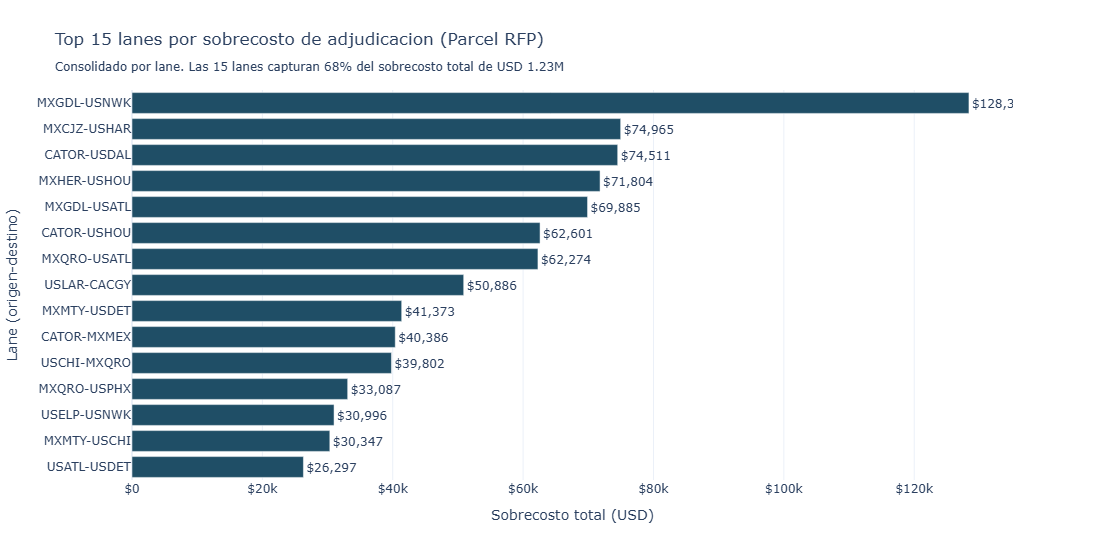

Lanes unicas mal adjudicadas: 55
Top 3 lanes:  USD 277,871  (23%)
Top 15 lanes: USD 837,609  (68%)
Lanes afectadas en +1 ronda: 12


In [46]:
# === Grafica Pareto: top 15 lanes por sobrecosto (consolidado por lane) ===

# Consolidar por lane: una lane mal adjudicada en varias rondas suma su sobrecosto
rfp_por_lane = (
    rfp_impacto.groupby("lane_id")
    .agg(
        sobrecosto_total=("sobrecosto_total", "sum"),
        n_rondas_afectadas=("rfp_year", "nunique"),
        n_envios_afectados=("n_envios_afectados", "sum"),
    )
    .sort_values("sobrecosto_total", ascending=False)
    .reset_index()
)

TOP = 15
top_lanes = rfp_por_lane.head(TOP).copy()
pct_top = top_lanes["sobrecosto_total"].sum() / total_rfp * 100

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_lanes["lane_id"],
    x=top_lanes["sobrecosto_total"],
    orientation="h",
    marker_color="#1F4E66",
    text=[f"${v:,.0f}" for v in top_lanes["sobrecosto_total"]],
    textposition="outside",
    showlegend=False,
))

fig.update_layout(
    template="plotly_white",
    title=f"Top {TOP} lanes por sobrecosto de adjudicacion (Parcel RFP)<br>"
          f"<sub>Consolidado por lane. Las {TOP} lanes capturan {pct_top:.0f}% del sobrecosto total de USD {total_rfp/1e6:.2f}M</sub>",
    xaxis_title="Sobrecosto total (USD)",
    yaxis_title="Lane (origen-destino)",
    height=560,
    margin=dict(t=90, l=120),
    yaxis=dict(autorange="reversed"),  # mayor arriba, ya sin etiquetas duplicadas
)
fig.update_xaxes(tickprefix="$", separatethousands=True)
fig.show()

# Concentracion (consolidada)
print(f"Lanes unicas mal adjudicadas: {len(rfp_por_lane)}")
print(f"Top 3 lanes:  USD {rfp_por_lane.head(3)['sobrecosto_total'].sum():,.0f}  ({rfp_por_lane.head(3)['sobrecosto_total'].sum()/total_rfp:.0%})")
print(f"Top 15 lanes: USD {rfp_por_lane.head(15)['sobrecosto_total'].sum():,.0f}  ({pct_top:.0f}%)")
print(f"Lanes afectadas en +1 ronda: {(rfp_por_lane['n_rondas_afectadas'] > 1).sum()}")

*Sobrecosto consolidado por lane (sumando las rondas en que cada una fue mal adjudicada), multiplicado por los envíos Parcel reales de la lane desde el año de la adjudicación en adelante. Top 15 de 55 lanes únicas.*

**Adjudicar por encima del mejor postor cuesta USD 1.23M en paquetería.**

De las 360 adjudicaciones lane-ronda del proceso de RFP, 68 (18.9%) se otorgaron a un transportista que no era el más barato disponible — un sobrecosto promedio de USD 117.56 por envío que, multiplicado por el tráfico real de cada lane, suma **USD 1,229,096**. Es la segunda oportunidad más grande del análisis, 2.5× el sobrecosto de C006.

El dinero se concentra y por eso es capturable: **15 lanes acumulan el 68% del total**, y solo la peor —MXGDL-USNWK— vale USD 128,395. No hay que renegociar 55 lanes; atacar el top 15 recupera dos tercios del ahorro.

Y hay un patrón de proceso, no de azar: **12 lanes fueron mal adjudicadas en más de una ronda**. El mismo error se repite de un año a otro, lo que sugiere una regla de adjudicación que privilegia al transportista vigente (*incumbent*) sobre el precio. Corregir el criterio de adjudicación —no solo renegociar lanes puntuales— ataca la causa raíz.

*Alcance:* este análisis cubre únicamente lanes de paquetería (Parcel), el único modo presente en el proceso de RFP del dataset. No se extrapola al resto de la red.

### 5.2 — Parcel pesado: envíos que deberían ir en LTL

La paquetería (Parcel) está optimizada para envíos pequeños y frecuentes: tiene un costo fijo de despacho por paquete que se prorratea mal cuando el envío es pesado. A partir de cierto peso, ese mismo envío movido por LTL (*less-than-truckload*, tarifado por peso consolidado) sale más barato. El 3.4 ya detectó la señal: el Parcel cross-border cuesta 135% más por km, un costo fijo prorrateado sobre carga que no le corresponde.

La pregunta no es cuántos envíos Parcel son pesados, sino **cuánto se ahorraría moviéndolos por LTL** — comparando lo que pagaron como Parcel contra lo que habrían costado como LTL. Como no existe un precio LTL para un envío que se movió como Parcel, se estima desde el costo por kg real de los envíos LTL de la red, con supuestos explícitos y conservadores. Antes de cuantificar, exploramos el terreno.

In [47]:
# === 5.2 — Exploracion: Parcel pesado vs referencia LTL ===

# Confirmar columna de peso
cols_peso = [c for c in df.columns if any(k in c.lower()
             for k in ["weight", "peso", "kg", "kilo"])]
print("Columnas de peso candidatas:", cols_peso)

# Usar la primera columna de peso en kg que no sea un costo
peso_col = [c for c in cols_peso if "cost" not in c.lower() and "costo" not in c.lower()][0]
print(f"Usando columna de peso: '{peso_col}'\n")

# --- Parcel pesado ---
parcel = df[df["mode"] == "Parcel"]
UMBRAL_KG = 45

pesados = parcel[parcel[peso_col] > UMBRAL_KG]
print(f"Envios Parcel totales:      {len(parcel):,}")
print(f"Parcel > {UMBRAL_KG} kg:            {len(pesados):,}  ({len(pesados)/len(parcel):.1%})")
print(f"Peso mediano de esos:       {pesados[peso_col].median():.1f} kg")
print(f"Peso p90 de esos:           {pesados[peso_col].quantile(0.9):.1f} kg")
print(f"Costo total pagado (Parcel):USD {pesados['total_cost_usd'].sum():,.0f}")
print(f"Costo mediano por envio:    USD {pesados['total_cost_usd'].median():.2f}")

# --- Referencia LTL: costo por kg real ---
ltl = df[df["mode"] == "LTL"]
print(f"\n--- Referencia LTL ({len(ltl):,} envios) ---")
print(f"Costo/kg LTL mediano:  USD {ltl['costo_por_kg'].median():.4f}")
print(f"Costo/kg LTL media:    USD {ltl['costo_por_kg'].mean():.4f}")
print(f"Costo/kg LTL p75:      USD {ltl['costo_por_kg'].quantile(0.75):.4f}")

# --- Comparacion: costo/kg del Parcel pesado ---
print(f"\n--- Parcel pesado, costo/kg actual ---")
print(f"Costo/kg Parcel pesado mediano: USD {pesados['costo_por_kg'].median():.4f}")
print(f"(si Parcel pesado >> LTL/kg, hay oportunidad de reasignacion)")

Columnas de peso candidatas: ['weight_kg', 'chargeable_weight_kg', 'costo_por_kg']
Usando columna de peso: 'weight_kg'

Envios Parcel totales:      83,856
Parcel > 45 kg:            4,925  (5.9%)
Peso mediano de esos:       60.3 kg
Peso p90 de esos:           68.0 kg
Costo total pagado (Parcel):USD 3,215,367
Costo mediano por envio:    USD 621.10

--- Referencia LTL (52,519 envios) ---
Costo/kg LTL mediano:  USD 1.5402
Costo/kg LTL media:    USD 1.6326
Costo/kg LTL p75:      USD 2.1958

--- Parcel pesado, costo/kg actual ---
Costo/kg Parcel pesado mediano: USD 10.6696
(si Parcel pesado >> LTL/kg, hay oportunidad de reasignacion)


In [48]:
# === 5.2 — Ahorro estimado por reasignar Parcel pesado a LTL ===

peso_col = "weight_kg"
UMBRAL_KG = 45
pesados = df[(df["mode"] == "Parcel") & (df[peso_col] > UMBRAL_KG)].copy()

# Referencia LTL conservadora: p75 (mas caro que la mediana -> subestima el ahorro)
ltl = df[df["mode"] == "LTL"]
costo_kg_ltl_ref = ltl["costo_por_kg"].quantile(0.75)
print(f"Referencia LTL usada (p75, conservadora): USD {costo_kg_ltl_ref:.4f}/kg")

# Costo estimado si se movieran por LTL
pesados["costo_ltl_estimado"] = pesados[peso_col] * costo_kg_ltl_ref
pesados["ahorro_envio"] = (pesados["total_cost_usd"] - pesados["costo_ltl_estimado"]).clip(lower=0)

ahorro_total = pesados["ahorro_envio"].sum()
n_con_ahorro = (pesados["ahorro_envio"] > 0).sum()

print(f"\nEnvios Parcel pesados analizados: {len(pesados):,}")
print(f"Envios con ahorro positivo:      {n_con_ahorro:,}  ({n_con_ahorro/len(pesados):.1%})")
print(f"Costo actual como Parcel:        USD {pesados['total_cost_usd'].sum():,.0f}")
print(f"Costo estimado como LTL:         USD {pesados['costo_ltl_estimado'].sum():,.0f}")
print(f"\n*** AHORRO ESTIMADO (Parcel->LTL): USD {ahorro_total:,.0f} ***")
print(f"Ahorro promedio por envio:       USD {ahorro_total/len(pesados):,.2f}")

# Sanidad: proporcion del costo original que se ahorra
print(f"\nReduccion sobre el costo actual: {ahorro_total/pesados['total_cost_usd'].sum():.0%}")

Referencia LTL usada (p75, conservadora): USD 2.1958/kg

Envios Parcel pesados analizados: 4,925
Envios con ahorro positivo:      4,733  (96.1%)
Costo actual como Parcel:        USD 3,215,367
Costo estimado como LTL:         USD 642,071

*** AHORRO ESTIMADO (Parcel->LTL): USD 2,583,514 ***
Ahorro promedio por envio:       USD 524.57

Reduccion sobre el costo actual: 80%


**Mover el Parcel pesado a LTL ahorra USD 2.58M — con una estimación deliberadamente conservadora.**

4,925 envíos de paquetería pesan más de 45 kg (mediana 60 kg), territorio claramente de LTL, no de Parcel. Pagan un costo por kg de **USD 10.67**, casi **7× el del LTL** (USD 1.54 mediano). Es el costo fijo de despacho de paquetería prorrateado sobre carga que le queda grande — exactamente la señal que el Bloque 3.4 había detectado en el Parcel cross-border.

Reasignados a LTL, esos envíos costarían USD 642K en vez de USD 3.22M: un ahorro de **USD 2,583,514**, una reducción del 80%. El **96% de los envíos** se benefician, así que no es un puñado de casos extremos sino un error sistemático de asignación de modo.

*Rigor de la estimación:* el costo LTL se calculó con la referencia **p75** (el LTL caro, no el típico), lo que subestima el ahorro a propósito; con la mediana sería mayor. Aun así, es un ahorro *identificado*, no garantizado: la migración real depende de que cada lane tenga servicio LTL disponible y de que el envío no exija la velocidad de la paquetería. La cifra marca el tamaño de la oportunidad, no un cheque firmado.

### 5.3 — Claims: cuánto de lo no recuperado es realmente perseguible

El Bloque 4.1 mostró que de USD 5.50M reclamados, solo vuelven 2.74M (49.9%), dejando 2.76M sin recuperar. Pero ese bruto no es todo cobrable: un claim negado puede estarlo con razón. Para no inflar el consolidado, hay que descomponer la brecha (reclamado − recuperado) **por estado del claim** y quedarnos solo con la parte defendible.

La recuperabilidad varía por estado: los *Open* (sin resolver) son dinero legítimamente en proceso; los *Partially Paid* y *Approved* tienen brechas que pueden disputarse; los *Denied* son los más dudosos. Cuantificamos cada uno por separado y definimos un estimado conservador.

In [49]:
# === 5.3 — Brecha reclamado vs recuperado, por estado del claim ===

por_estado = (
    claims.groupby("claim_status")
    .agg(
        n_claims=("claim_id", "count"),
        reclamado=("claim_amount_usd", "sum"),
        recuperado=("recovered_usd", "sum"),
    )
    .reset_index()
)
por_estado["brecha"] = por_estado["reclamado"] - por_estado["recuperado"]
por_estado["tasa_recup"] = por_estado["recuperado"] / por_estado["reclamado"]
por_estado = por_estado.sort_values("brecha", ascending=False)

print(por_estado.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

print(f"\n--- Totales ---")
print(f"Brecha total (reclamado - recuperado): USD {por_estado['brecha'].sum():,.0f}")

# Estimado conservador: Open al 100% de su brecha (en proceso legitimo),
# Partially Paid y Approved al 50% (disputa incierta), Denied excluido (0%)
pesos = {"Open": 1.0, "Partially Paid": 0.5, "Approved": 0.5, "Denied": 0.0}
por_estado["factor"] = por_estado["claim_status"].map(pesos).fillna(0.0)
por_estado["recuperable_est"] = por_estado["brecha"] * por_estado["factor"]

recuperable = por_estado["recuperable_est"].sum()
print(f"\n--- Estimado conservador de recuperable ---")
print(por_estado[["claim_status", "brecha", "factor", "recuperable_est"]].to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print(f"\n*** RECUPERABLE ESTIMADO (conservador): USD {recuperable:,.0f} ***")


  claim_status  n_claims    reclamado   recuperado       brecha  tasa_recup
        Denied       381 1,337,606.40         0.00 1,337,606.40        0.00
          Open       350   816,478.68         0.00   816,478.68        0.00
Partially Paid       443 1,146,252.50   544,649.21   601,603.29        0.48
      Approved       915 2,198,142.70 2,198,142.70         0.00        1.00

--- Totales ---
Brecha total (reclamado - recuperado): USD 2,755,688

--- Estimado conservador de recuperable ---
  claim_status       brecha  factor  recuperable_est
        Denied 1,337,606.40    0.00             0.00
          Open   816,478.68    1.00       816,478.68
Partially Paid   601,603.29    0.50       300,801.65
      Approved         0.00    0.50             0.00

*** RECUPERABLE ESTIMADO (conservador): USD 1,117,280 ***


**De los USD 2.76M sin recuperar, solo USD 1.12M son realistamente perseguibles — la otra mitad son claims negados.**

Descomponer la brecha por estado revela un sistema binario: los claims **Approved se pagan al 100%** (sin brecha que perseguir) y los **Denied al 0%** (brecha de USD 1.34M que probablemente no se recupera). Reportar los 2.76M brutos como "recuperable" habría duplicado la cifra real.

El estimado conservador toma solo lo defendible: los **Open** (USD 816K, claims aún en proceso, legítimamente cobrables) al 100%, los **Partially Paid** (USD 602K) al 50% por la incertidumbre de disputa, y **excluye por completo los Denied**. Resultado: **USD 1,117,280** recuperables.

Hay una segunda oportunidad, cualitativa: 381 claims negados por USD 1.34M es un volumen alto. La pregunta no es solo cómo cobrarlos, sino **por qué se niegan** — si la causa es documentación deficiente al presentarlos, corregir el proceso de reclamación recuperaría valor aguas arriba, antes de que el claim se niegue. Es una mejora de proceso, no de cobranza.

### 5.4 — Síntesis: la cifra titular

Cuatro líneas de oportunidad sobrevivieron al escrutinio. No todas tienen el mismo grado de certeza, y presentarlas honestamente por nivel de confianza es más creíble —y más útil para decidir— que sumar un solo número.

- **Núcleo medido (alta certeza):** sobrecosto de C006 y lanes RFP mal adjudicadas. Son cifras calculadas sobre transacciones reales, no estimaciones.
- **Capa estimada (supuestos explícitos):** reasignación de Parcel pesado a LTL y recuperación de claims. Dependen de que la migración de modo sea viable y de que los claims en proceso se cobren. Cuantificadas de forma conservadora.

El caso de negocio se presenta como un rango: lo que se puede afirmar con confianza, y el potencial total si las reasignaciones se materializan.

In [50]:
# === 5.4 — Consolidado de oportunidades por nivel de confianza ===

oportunidades = pd.DataFrame([
    {"oportunidad": "Sobrecosto C006 (accesoriales)", "usd": 486_132,   "nivel": "Medido",    "bloque": "3.2"},
    {"oportunidad": "Lanes RFP mal adjudicadas",       "usd": 1_229_096, "nivel": "Medido",    "bloque": "5.1"},
    {"oportunidad": "Parcel pesado -> LTL",            "usd": 2_583_514, "nivel": "Estimado",  "bloque": "5.2"},
    {"oportunidad": "Claims recuperables",             "usd": 1_117_280, "nivel": "Estimado",  "bloque": "5.3"},
])

# Ordenar por monto dentro del consolidado
oportunidades = oportunidades.sort_values("usd", ascending=False).reset_index(drop=True)

# Subtotales por nivel
medido   = oportunidades.loc[oportunidades["nivel"] == "Medido", "usd"].sum()
estimado = oportunidades.loc[oportunidades["nivel"] == "Estimado", "usd"].sum()
total    = oportunidades["usd"].sum()

print(oportunidades.to_string(index=False, float_format=lambda x: f"{x:,.0f}"))
print(f"\n{'='*50}")
print(f"NUCLEO MEDIDO (alta certeza):   USD {medido:,.0f}")
print(f"CAPA ESTIMADA (con supuestos):  USD {estimado:,.0f}")
print(f"{'='*50}")
print(f"POTENCIAL TOTAL IDENTIFICADO:   USD {total:,.0f}")
print(f"{'='*50}")

# Contexto: como % del gasto total de la red
GASTO_RED = 464_533_185
print(f"\nComo % del gasto total de la red (USD {GASTO_RED/1e6:.0f}M):")
print(f"  Nucleo medido:  {medido/GASTO_RED:.2%}")
print(f"  Total:          {total/GASTO_RED:.2%}")

                   oportunidad     usd    nivel bloque
          Parcel pesado -> LTL 2583514 Estimado    5.2
     Lanes RFP mal adjudicadas 1229096   Medido    5.1
           Claims recuperables 1117280 Estimado    5.3
Sobrecosto C006 (accesoriales)  486132   Medido    3.2

NUCLEO MEDIDO (alta certeza):   USD 1,715,228
CAPA ESTIMADA (con supuestos):  USD 3,700,794
POTENCIAL TOTAL IDENTIFICADO:   USD 5,416,022

Como % del gasto total de la red (USD 465M):
  Nucleo medido:  0.37%
  Total:          1.17%


    La gráfica consolida las cuatro oportunidades separadas por nivel de confianza. El color distingue lo medido sobre transacciones reales (azul oscuro) de lo estimado bajo supuestos explícitos (arena). El caso de negocio se lee como un rango: un piso firme de USD 1.72M y un techo de USD 5.42M si las reasignaciones se materializan.

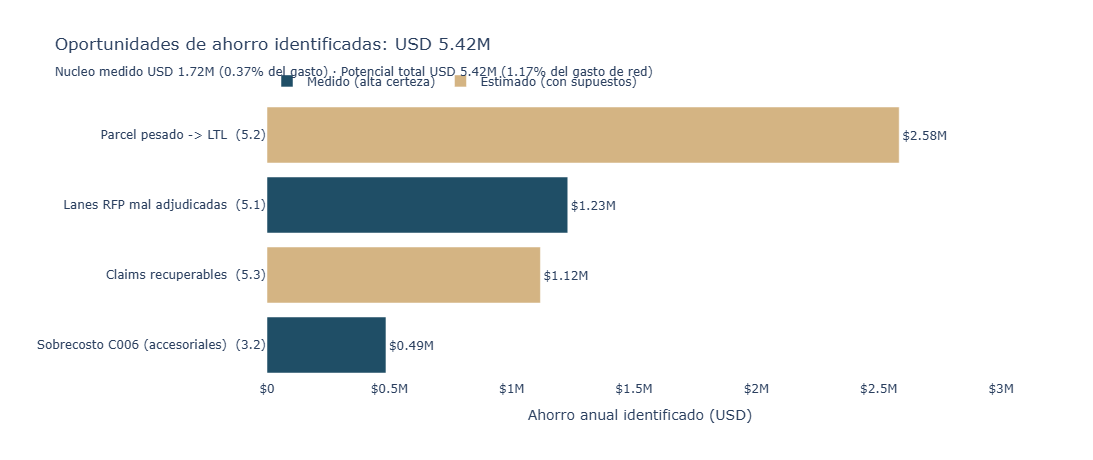

In [51]:
# === 5.4 — Grafica titular: oportunidades por nivel de confianza ===

# Colores por nivel
color_map = {"Medido": "#1F4E66", "Estimado": "#D4B483"}
barra_colors = [color_map[n] for n in oportunidades["nivel"]]

# Etiqueta con monto y bloque
labels = [f"{o}  ({b})" for o, b in zip(oportunidades["oportunidad"], oportunidades["bloque"])]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=labels,
    x=oportunidades["usd"],
    orientation="h",
    marker_color=barra_colors,
    text=[f"${v/1e6:.2f}M" for v in oportunidades["usd"]],
    textposition="outside",
    showlegend=False,
))

# Leyenda manual con dos trazas invisibles (para explicar el color)
fig.add_trace(go.Bar(y=[None], x=[None], marker_color="#1F4E66", name="Medido (alta certeza)"))
fig.add_trace(go.Bar(y=[None], x=[None], marker_color="#D4B483", name="Estimado (con supuestos)"))

fig.update_layout(
    template="plotly_white",
    title=f"Oportunidades de ahorro identificadas: USD {total/1e6:.2f}M<br>"
          f"<sub>Nucleo medido USD {medido/1e6:.2f}M (0.37% del gasto) · Potencial total USD {total/1e6:.2f}M (1.17% del gasto de red)</sub>",
    xaxis_title="Ahorro anual identificado (USD)",
    yaxis_title="",
    height=460,
    margin=dict(t=100, l=260),
    legend=dict(orientation="h", y=1.12, x=0),
    yaxis=dict(autorange="reversed"),
)
fig.update_xaxes(tickprefix="$", separatethousands=True, range=[0, oportunidades["usd"].max()*1.18])
fig.show()

*Cuatro oportunidades ordenadas por monto. Azul: cifras medidas sobre transacciones reales. Arena: estimaciones conservadoras bajo supuestos explícitos. El bloque entre paréntesis remite al análisis que la sustenta.*

**El diagnóstico identifica hasta USD 5.42M en ahorro anual — con un piso firme de USD 1.72M.**

El análisis convierte cuatro hallazgos dispersos en un caso de negocio con dos niveles de certeza. El **núcleo medido (USD 1.72M)** no depende de supuestos: el sobrecosto de accesoriales de C006 (USD 486K, verificado por dos métodos) y las lanes de paquetería mal adjudicadas en el RFP (USD 1.23M, sobrecosto real sobre envíos reales). Es dinero que puede recuperarse renegociando contratos y corrigiendo el criterio de adjudicación, sin cambiar nada operativo.

La **capa estimada (USD 3.70M)** amplía el potencial bajo supuestos declarados: reasignar el Parcel pesado a LTL (USD 2.58M, si las lanes admiten la migración) y perseguir los claims cobrables (USD 1.12M, ya descontados los negados). Son oportunidades reales pero condicionadas, cuantificadas de forma deliberadamente conservadora.

En conjunto, **1.17% del gasto anual de la red (USD 464.5M)**. No es una cifra transformadora —y presentarla como tal restaría credibilidad—; es un ahorro material, defendible y accionable, con una jerarquía clara de por dónde empezar: el núcleo medido primero, la capa estimada según se validen sus supuestos.

---

### Cierre del Bloque 5 — Oportunidades cuantificadas

El proyecto empezó con 219,120 embarques y USD 464.5M de gasto sin estructura. Seis bloques después, ese gasto tiene un diagnóstico: dónde se pierde dinero, cuánto, con qué certeza, y qué hacer al respecto. El rigor fue tan importante como las cifras — tres de las cuatro oportunidades que el planteamiento inicial sugería como recuperables no sobrevivieron al escrutinio (subcobro de combustible, facturación bruta, premium por incoterm), y descartarlas es lo que hace creíbles las que quedaron.

Lo que sigue no es más análisis, es traducción: llevar estos hallazgos a SQL (para reproducibilidad), a un dashboard de Power BI (para consumo ejecutivo) y al caso de negocio del README (para el portafolio). La historia analítica está completa; ahora se empaqueta.

In [52]:
# Diagnostico temporal: ver que DataFrames hay en memoria
for nombre, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and not nombre.startswith('_'):
        print(f"{nombre:25s} {obj.shape}")

df                        (219120, 43)
carrier                   (30, 9)
site                      (30, 8)
claims                    (2089, 8)
rfp                       (1441, 8)
fuel                      (183, 3)
events                    (376816, 3)
tabla                     (6, 4)
panorama                  (6, 6)
comp                      (6, 5)
mensual                   (42, 4)
por_mes                   (12, 3)
completos                 (36, 7)
est                       (12, 2)
otd_modo_mes              (252, 3)
foco                      (84, 4)
plot                      (6, 6)
plot_ord                  (6, 6)
dray                      (42, 3)
vent                      (16, 3)
df_ev                     (219120, 44)
ev                        (376816, 3)
hitos                     (90000, 5)
tramos                    (89638, 6)
prop                      (89638, 9)
aud                       (89638, 7)
falsos_neg                (44835, 7)
falsos_pos                (6773, 7)
resumen     

In [53]:
# Diagnostico: inspeccionar candidatas al scorecard 4.3
print("=== por_carrier ===")
print(por_carrier.columns.tolist())
print(por_carrier.head(3))

=== por_carrier ===
['embarques', 'var_media', 'var_total', 'carrier_name', 'carrier_tier']
            embarques  var_media  var_total          carrier_name carrier_tier
carrier_id                                                                    
C003            18612  16.205831  301622.92    Werner Enterprises         Core
C025            14312  20.566597  294349.13          Maersk Ocean    Strategic
C029             8155  18.998542  154933.11  Drayage Solutions LA         Core


In [54]:
# Diagnostico: ver estados de claims y si hay tabla de recuperables
print("=== claims_tier columnas ===")
print(claims_tier.columns.tolist())
print("\n=== estados de claim disponibles ===")
print(claims['claim_status'].value_counts())

=== claims_tier columnas ===
['claim_id', 'shipment_id', 'carrier_id', 'claim_date', 'claim_type', 'claim_amount_usd', 'claim_status', 'recovered_usd', 'carrier_name', 'carrier_tier']

=== estados de claim disponibles ===
claim_status
Approved          915
Partially Paid    443
Denied            381
Open              350
Name: count, dtype: int64


In [55]:
# Diagnostico: confirmar que 'oportunidades' es la tabla titular del 5.4
print(oportunidades)

                      oportunidad      usd     nivel bloque
0            Parcel pesado -> LTL  2583514  Estimado    5.2
1       Lanes RFP mal adjudicadas  1229096    Medido    5.1
2             Claims recuperables  1117280  Estimado    5.3
3  Sobrecosto C006 (accesoriales)   486132    Medido    3.2


In [56]:
# Diagnostico: encontrar el scorecard real del 4.3
for nombre in ['sc_envios', 'sc_claims', 'sc_style', 'completos']:
    obj = globals().get(nombre)
    if obj is not None:
        print(f"=== {nombre} {obj.shape} ===")
        print(obj.columns.tolist())
        print()

=== sc_envios (30, 5) ===
['carrier_id', 'n_embarques', 'costo_total_usd', 'otd', 'costo_x_embarque']

=== sc_claims (29, 3) ===
['carrier_id', 'n_claims', 'reclamado_usd']

=== sc_style (30, 8) ===
['carrier_name', 'carrier_tier', 'n_embarques', 'costo_x_embarque', 'otd', 'tasa_reclamacion_x1000', 'costo_dano_x_embarque', 'costo_real_x_embarque']

=== completos (36, 7) ===
['mes', 'embarques', 'gasto_usd', 'otd', 'mes_num', 'anio', 'idx_anual']



In [59]:
# Export 1/N: tabla titular del 5.4 (las 4 oportunidades por nivel)
oportunidades.to_pickle(RUTA_DASH / "oportunidades.pkl")
print("Exportado: oportunidades.pkl")
print(oportunidades)

Exportado: oportunidades.pkl
                      oportunidad      usd     nivel bloque
0            Parcel pesado -> LTL  2583514  Estimado    5.2
1       Lanes RFP mal adjudicadas  1229096    Medido    5.1
2             Claims recuperables  1117280  Estimado    5.3
3  Sobrecosto C006 (accesoriales)   486132    Medido    3.2


In [60]:
# Export 2/N: scorecard de costo real del 4.3 (30 carriers)
sc_style.to_pickle(RUTA_DASH / "scorecard.pkl")
print("Exportado: scorecard.pkl")
print(sc_style[['carrier_name','carrier_tier','costo_real_x_embarque','costo_dano_x_embarque','tasa_reclamacion_x1000','otd']].head())

Exportado: scorecard.pkl
   carrier_name carrier_tier  costo_real_x_embarque  costo_dano_x_embarque  tasa_reclamacion_x1000       otd
0   Hapag Lloyd         Core            4963.882217              22.808313                6.024096  0.683047
1  Maersk Ocean    Strategic            4896.857733              46.631029                7.126887  0.676785
2     MSC Ocean         Core            4691.339619              26.704146                4.177546  0.600105
3       CMA CGM     Tactical            4665.902124              14.339935                6.535948  0.591362
4       JB Hunt    Strategic            4524.346733              52.966676                8.513053  0.888169


In [61]:
# Export 3/N: RFP mal adjudicadas del 5.1 (detalle + top consolidado)
rfp_impacto.to_pickle(RUTA_DASH / "rfp_detalle.pkl")

# Consolidar por lane (suma sobre rondas) para el Pareto, mayor-arriba
col_lane = 'lane_id' if 'lane_id' in rfp_impacto.columns else rfp_impacto.columns[0]
col_usd = [c for c in rfp_impacto.columns if 'usd' in c.lower() or 'impacto' in c.lower() or 'sobrecosto' in c.lower()]
print("Columnas de rfp_impacto:", rfp_impacto.columns.tolist())
print("Columna lane detectada:", col_lane)
print("Columnas USD candidatas:", col_usd)

Columnas de rfp_impacto: ['lane_id', 'rfp_year', 'sobrecosto_x_envio', 'n_envios_afectados', 'sobrecosto_total']
Columna lane detectada: lane_id
Columnas USD candidatas: ['sobrecosto_x_envio', 'sobrecosto_total']


In [62]:
# Export 4/N: resumen Parcel->LTL del 5.2 (cifras clave, sin filas crudas)
resumen_parcel_ltl = pd.DataFrame([{
    'envios_pesados': len(pesados),
    'mediana_peso_kg': pesados['weight_kg'].median(),
    'usd_por_kg_parcel': pesados['costo_por_kg'].median(),
    'ahorro_estimado_usd': 2583514
}])
resumen_parcel_ltl.to_pickle(RUTA_DASH / "parcel_ltl_resumen.pkl")
print("Exportado: parcel_ltl_resumen.pkl")
print(resumen_parcel_ltl.T)

Exportado: parcel_ltl_resumen.pkl
                                0
envios_pesados       4.925000e+03
mediana_peso_kg      6.030000e+01
usd_por_kg_parcel    1.066956e+01
ahorro_estimado_usd  2.583514e+06


In [63]:
# Export 5/N: claims recuperables del 5.3 (reconstruido por estado)
sin_recuperar = claims['claim_amount_usd'] - claims['recovered_usd']
por_estado = claims.assign(pendiente=sin_recuperar).groupby('claim_status')['pendiente'].sum()

recuperables = pd.DataFrame([
    {'estado': 'Open',           'pendiente_usd': por_estado.get('Open', 0),           'factor': 1.0},
    {'estado': 'Partially Paid', 'pendiente_usd': por_estado.get('Partially Paid', 0), 'factor': 0.5},
])
recuperables['recuperable_usd'] = recuperables['pendiente_usd'] * recuperables['factor']
recuperables.to_pickle(RUTA_DASH / "claims_recuperables.pkl")
print("Exportado: claims_recuperables.pkl")
print(recuperables)
print(f"\nTotal recuperable: USD {recuperables['recuperable_usd'].sum():,.0f}")

Exportado: claims_recuperables.pkl
           estado  pendiente_usd  factor  recuperable_usd
0            Open      816478.68     1.0       816478.680
1  Partially Paid      601603.29     0.5       300801.645

Total recuperable: USD 1,117,280


In [64]:
# Export 3b/N: consolidado por lane para el Pareto (suma sobre rondas)
top_lanes_pareto = (rfp_impacto
    .groupby('lane_id', as_index=False)['sobrecosto_total']
    .sum()
    .sort_values('sobrecosto_total', ascending=False)
    .reset_index(drop=True))
top_lanes_pareto.to_pickle(RUTA_DASH / "rfp_top_lanes.pkl")
print("Exportado: rfp_top_lanes.pkl")
print(f"Lanes unicas: {len(top_lanes_pareto)}")
print(f"Sobrecosto total: USD {top_lanes_pareto['sobrecosto_total'].sum():,.0f}")
print(top_lanes_pareto.head(15))

Exportado: rfp_top_lanes.pkl
Lanes unicas: 55
Sobrecosto total: USD 1,229,096
        lane_id  sobrecosto_total
0   MXGDL-USNWK         128395.18
1   MXCJZ-USHAR          74965.44
2   CATOR-USDAL          74510.80
3   MXHER-USHOU          71803.84
4   MXGDL-USATL          69884.56
5   CATOR-USHOU          62600.52
6   MXQRO-USATL          62274.30
7   USLAR-CACGY          50885.80
8   MXMTY-USDET          41373.36
9   CATOR-MXMEX          40385.66
10  USCHI-MXQRO          39801.60
11  MXQRO-USPHX          33087.10
12  USELP-USNWK          30996.24
13  MXMTY-USCHI          30346.81
14  USATL-USDET          26297.37
